# Initialization

In [1]:
import stim
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset #, DataLoader
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv

from wrappers.stim_wrapper import (create_circuit_polar_stim_normal, convert_i_to_meas_type, convert_i_to_zpos,
simulate_batch_and_save_result_polar_normal)

from wrappers.polar_wrapper import is_q1prep_accepted, get_logical_error_on_accepted_states, get_q1prep_accepted_states, q1prep_func

from wrappers.polar_wrapper import __polarcodec as codec
from wrappers.polar_wrapper.__qpolarprep import q1prep

import torch
from sklearn.metrics import precision_score, recall_score, f1_score

import torch
import torch.nn as nn
from torch_geometric.nn import GATv2Conv, JumpingKnowledge, global_mean_pool
import random
import torch
import numpy as np
from torch.utils.data import IterableDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv

import torch
import torch.nn as nn
import torch.optim as optim

from torch_geometric.loader import DataLoader

from collections import Counter
import random
import numpy as np
import torch
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data

import torch
from torch_geometric.loader import DataLoader


In [2]:

def create_stim_circuit_polar(n, i, lstate, sim_type, p_error, shots, seed):
    N = 2**(n)
    ancilla_qubits = 2**(n - 1)
    total_qubits = N + ancilla_qubits
    meas_type = convert_i_to_meas_type(i, n, lstate.lower())
    zpos = convert_i_to_zpos(i, n, lstate.lower())

    # print(zpos, meas_type, sim_type, "total qubits:", total_qubits, ", total ancilla:", ancilla_qubits)
    x_ind = 0
    for idx, m_type in enumerate(meas_type):
        if m_type == "x":
            x_ind = idx
            break

    circuit = create_circuit_polar_stim_normal(n, lstate, sim_type, p_error, seed, shots, None, None, None, meas_type, total_qubits, x_ind)
    return circuit

def set_global_seeds(seed=12345):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Quantum Polar Code

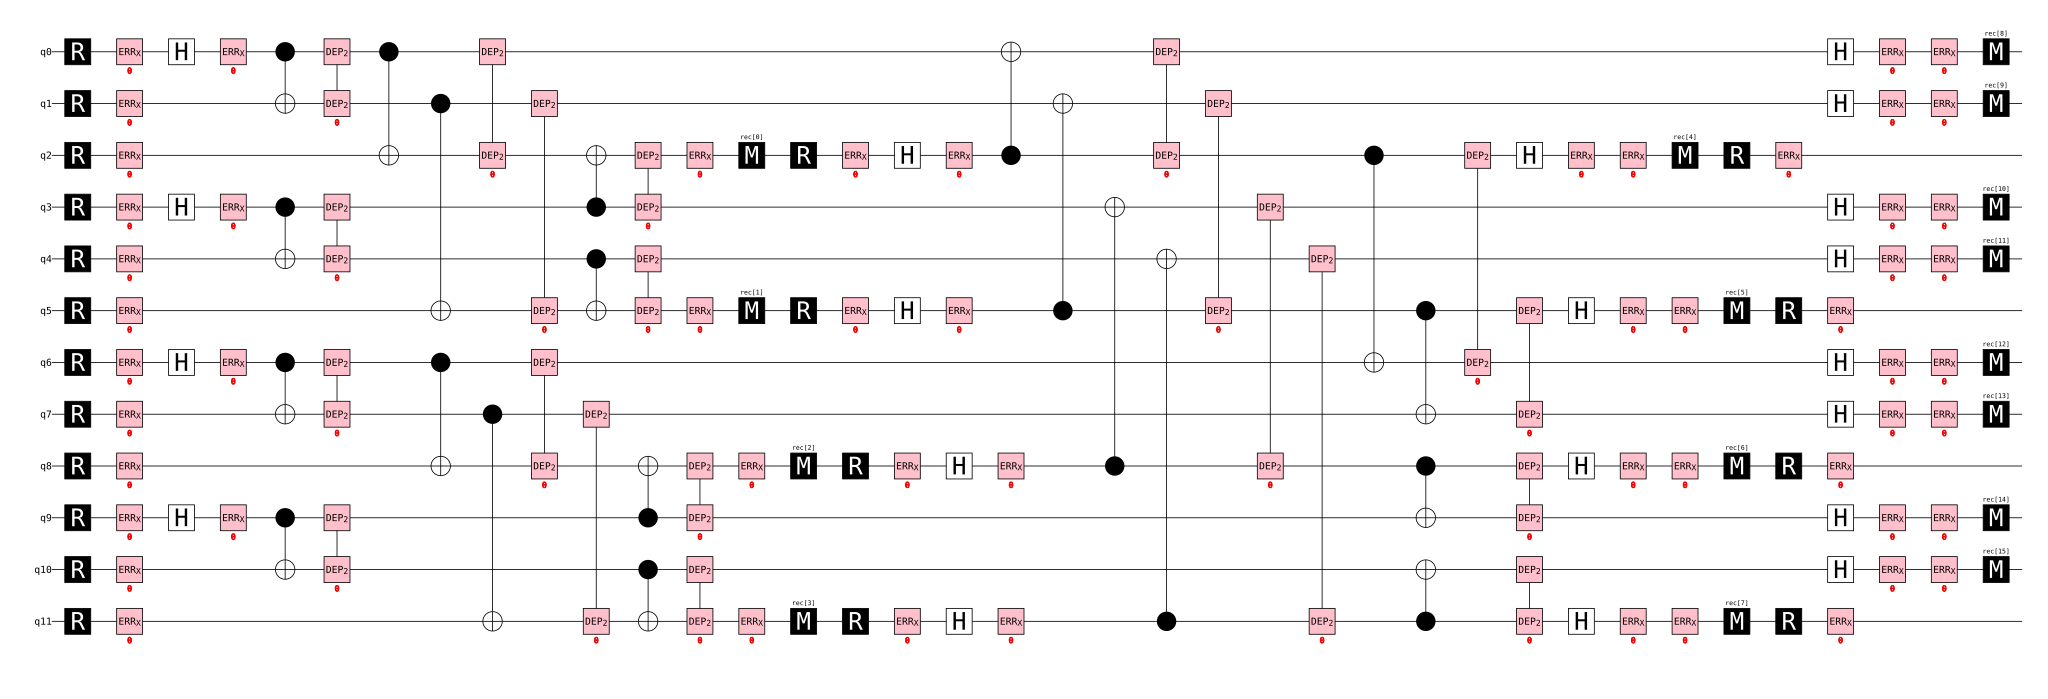

In [3]:
n = 3
i = 4
lstate = "x"
p_error = 0
shots = int(1e4)
seed = 1000

sim_type = "m1"
polar_n3 = create_stim_circuit_polar(n, i, lstate, sim_type, p_error, shots, seed)
polar_n3.diagram("timeline-svg")

In [4]:
from wrappers.stim_wrapper import (
    simulate_stim_polar_code_normal)

n = 3
lstate = "x"
sim_type = "m1"
i = 4
p_error = 0.1
shots = 1e4
seed = 12345

zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1

results = simulate_stim_polar_code_normal(n, lstate, sim_type, i, p_error, shots, seed)

# flipped_results = {bit_str[::-1]: count for bit_str, count in results.items()}
sum(results.values())

10000

In [5]:
zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1


print(get_logical_error_on_accepted_states(n, lstate.upper(), results, zpos_list), zpos_list[n])

accepted_states, data_qubit_states = get_q1prep_accepted_states(n, lstate, results, zpos_list)
sum(data_qubit_states.values())

(1644, 806, 1427, 0.5097323600973236, 0, 0.8190117049998662) 3


1644

# QEC NN Decoder

## GNN Simple

In [6]:
def build_polar_butterfly_edge_index(n: int) -> torch.Tensor:
    """
    Generates PyTorch Geometric COO edge_index for an N = 2^n Polar Butterfly graph.
    Connects qubit pairs that interact across all n stages of the butterfly kernel.
    """
    N = 2**n
    source_edges = []
    target_edges = []

    # Iterate through each stage of the Polar Butterfly (s = 0, ..., n-1)
    for s in range(n):
        step = 2**s
        for i in range(0, N, 2 * step):
            for j in range(step):
                u = i + j
                v = i + j + step
                # Bidirectional message passing along butterfly connections
                source_edges.extend([u, v])
                target_edges.extend([v, u])

    edge_index = torch.tensor([source_edges, target_edges], dtype=torch.long)
    return edge_index

In [7]:
# Define your mapping options for zpos / information positions
ZPOS_MAPPINGS = {
    "option_1": {3: 4, 4: 6, 5: 8},
    "option_2": {3: 5, 4: 7, 5: 25}
}

def get_info_target_index(n: int, lstate: str, option: str = "option_1") -> int:
    """Returns the information qubit index target_idx for a given n, state, and mapping option."""
    mapping = ZPOS_MAPPINGS[option]
    base_idx = mapping[n]
    
    # # Adjust for X state if your convention offsets X vs Z by 1
    # if lstate.upper() == "X":
    #     return base_idx - 1
    return base_idx

def get_zpos_and_target_from_i(i: int, lstate: str) -> tuple[int, int]:
    """
    Computes 0-based zpos cutoff and target node index from a 1-based information position i.
    
    Examples:
      - n=3, i=4  => Z: zpos=3, target=3 | X: zpos=2, target=3
      - n=4, i=6  => Z: zpos=5, target=5 | X: zpos=4, target=5
      - n=5, i=25 => Z: zpos=24, target=24 | X: zpos=23, target=24
    """
    base_zpos = i - 1  # Convert 1-based i to 0-based index
    
    if lstate.upper() == "Z":
        zpos = base_zpos
    else:  # "X"
        zpos = base_zpos - 1
        
    target_idx = base_zpos  # Frame always sits at 0-based index (i - 1)
    return zpos, target_idx

In [8]:
def build_5channel_node_features(
    delta_data, 
    i, 
    lstate, 
    n, 
    p_error
):
    """
    Constructs the 5-channel feature matrix for N data qubits.
    Channels:
    0: delta_data (syndrome offset, 0 or 1)
    1: q / N (normalized spatial coordinate)
    2: state_flag (0.0 for Z, 1.0 for X)
    3: is_info_pos (1.0 at target_idx, 0.0 elsewhere)
    4: p_error (physical noise parameter)
    """
    # target_idx = get_info_target_index(n, lstate, option=mapping_option)
    zpos, target_idx = get_zpos_and_target_from_i(i, lstate)
    N = int(2**n)

    # Construct 5-channel feature matrix dynamically scaled to N = 2^n
    state_flag = 0.0 if lstate.upper() == "Z" else 1.0
    node_features = []
    
    for q in range(N):
        is_info_pos = 1.0 if q == target_idx else 0.0
        node_features.append([
            float(delta_data[q]),
            float(q / N),
            state_flag,
            is_info_pos,
            float(p_error)
        ])
        
    return node_features, target_idx

In [9]:
import random
import torch
import numpy as np
from torch_geometric.data import Data

def prepare_gnn_dataset_from_shots(
    results,       # Dict of {meas_str: count}
    n, 
    i,                  # 1-based information index
    lstate, 
    p_error,
    codec,              # Polar C-extension / Python module
    q1prep_func
):
    """
    Processes accepted shots into a pre-generated PyG Data list in RAM.
    Integrates 5-channel features and 50/50 target balancing.
    """
    N = 2**n
    zpos, target_idx = get_zpos_and_target_from_i(i, lstate)
    edge_index = build_polar_butterfly_edge_index(n)
    
    data_list = []

    for mstr in results:
        mstr = mstr.strip()
        meas = np.array([ord(c) - ord('0') for c in mstr], dtype=int)

        aux_meas = meas[:N-1:-1]
        data_meas = meas[N-1::-1]

        # Stage 1: Verification
        success, qstate_UV = q1prep_func(n, zpos, aux_meas)
        if success == 0:
            continue  # Discard rejected shots

        logical_bit = random.choice([0, 1])

        if lstate.upper() == "Z":
            qstate_U = np.zeros((N,), dtype=int)
            qstate_U[:zpos] = qstate_UV[:zpos]
            qstate_U[zpos] = logical_bit

            codec.polarenc(qstate_U)
            delta_data = np.mod(data_meas + qstate_U, 2)
            true_bit = int(np.mod(qstate_UV[zpos] + logical_bit, 2))

        else:  # X state
            qstate_V = np.zeros((N,), dtype=int)
            qstate_V[zpos+2:] = qstate_UV[zpos+2:]
            qstate_V[zpos+1] = logical_bit

            codec.revpolarenc(qstate_V)
            delta_data = np.mod(data_meas + qstate_V, 2)
            true_bit = int(np.mod(qstate_UV[zpos+1] + logical_bit, 2))

        # Build 5-channel node features
        node_features, _ = build_5channel_node_features(
            delta_data, i, lstate, n, p_error
        )

        x = torch.tensor(node_features, dtype=torch.float32)
        y = torch.tensor([true_bit], dtype=torch.float32)

        data_list.append(Data(x=x, edge_index=edge_index, y=y))

    return data_list

In [10]:
# 2. Generate a batch of shots from Stim circuit using p and lstate
n = 3
N = 2**n
i = 4
lstate = "x"
p_error = 0.0025
shots = int(10)
seed = 10000
sim_type = "m1"

def sample_stim_generation(n, i, lstate, sim_type, p_error, shots, seed):

    circuit = create_stim_circuit_polar(n, i, lstate, sim_type, p_error, shots, seed)

    # print(n, i, lstate, sim_type, p_error, shots, seed)

    sampler_noisy = circuit.compile_sampler(seed=seed)
    results = sampler_noisy.sample(shots=shots)
    counts = []
    for res in results:
        bit_string = ""
        for j in res:
            if j:
                bit_string = "1" + bit_string 
            else:
                bit_string = "0" + bit_string

        if sim_type in ["m1", "m2", "m3"]:
            bit_string = bit_string + "0"*(2**(n - 1))

        # print(sim_type, bit_string)

        counts.append(bit_string)

    return counts



In [11]:
results = sample_stim_generation(n, i, lstate, sim_type, p_error, shots, seed)

# 1. Pre-generate data once
train_data_list = prepare_gnn_dataset_from_shots(results,       # Dict of {meas_str: count}
    n, 
    i,                  # 1-based information index
    lstate, 
    p_error,
    codec,              # Polar C-extension / Python module
    q1prep)


In [12]:
train_data_list

[Data(x=[8, 5], edge_index=[2, 24], y=[1]),
 Data(x=[8, 5], edge_index=[2, 24], y=[1]),
 Data(x=[8, 5], edge_index=[2, 24], y=[1]),
 Data(x=[8, 5], edge_index=[2, 24], y=[1]),
 Data(x=[8, 5], edge_index=[2, 24], y=[1]),
 Data(x=[8, 5], edge_index=[2, 24], y=[1]),
 Data(x=[8, 5], edge_index=[2, 24], y=[1]),
 Data(x=[8, 5], edge_index=[2, 24], y=[1]),
 Data(x=[8, 5], edge_index=[2, 24], y=[1]),
 Data(x=[8, 5], edge_index=[2, 24], y=[1])]

#### Function Generating Data set

In [13]:
import random
import numpy as np
import torch
from torch.utils.data import IterableDataset
from torch_geometric.data import Data

class StreamingQPCDataset(IterableDataset):
    def __init__(
        self, 
        n, 
        i,
        lstate,
        sim_type,
        codec, 
        q1prep_func, 
        stim_sampler_func, 
        p_min=0.001, 
        p_max=0.05,
        max_samples=100000,
        stim_chunk_size=500,    # Reduced to 500 for high p_error turnover
        buffer_size=10000,      # Shuffles graphs across ~20 different chunks
        seed=12345
    ):
        super().__init__()
        self.n = n
        self.i = i
        self.lstate = lstate.upper()
        self.sim_type = sim_type
        self.N = int(2**n)
        self.codec = codec
        self.q1prep_func = q1prep_func
        self.stim_sampler_func = stim_sampler_func
        self.p_min = p_min
        self.p_max = p_max
        self.max_samples = max_samples
        self.edge_index = build_polar_butterfly_edge_index(n)
        self.stim_chunk_size = stim_chunk_size
        self.buffer_size = buffer_size
        self.seed = seed

    def __iter__(self):
        buffer = []
        samples_yielded = 0

        while samples_yielded < self.max_samples or len(buffer) > 0:
            # Fill the buffer with graphs from multiple distinct p_error chunks
            while len(buffer) < self.buffer_size and samples_yielded < self.max_samples:
                p_error = random.uniform(self.p_min, self.p_max)
                zpos, target_idx = get_zpos_and_target_from_i(self.i, self.lstate)

                raw_shots = self.stim_sampler_func(
                    self.n, self.i, self.lstate, self.sim_type, 
                    p_error, self.stim_chunk_size, self.seed
                )

                for shot_str in raw_shots:
                    meas = np.array([ord(c) - ord('0') for c in shot_str], dtype=int)
                    aux_meas = meas[:self.N-1:-1]
                    data_meas = meas[self.N-1::-1]

                    success, qstate_UV = self.q1prep_func(self.n, zpos, aux_meas)
                    if success == 0:
                        continue  # Skip rejected states

                    logical_bit = random.choice([0, 1])

                    if self.lstate == "Z":
                        qstate_U = np.zeros((self.N,), dtype=int)
                        qstate_U[:zpos] = qstate_UV[:zpos]
                        qstate_U[zpos] = logical_bit

                        self.codec.polarenc(qstate_U)
                        delta_data = np.mod(data_meas + qstate_U, 2)
                        true_bit = int(np.mod(qstate_UV[zpos] + logical_bit, 2))
                    else:  # X state
                        qstate_V = np.zeros((self.N,), dtype=int)
                        qstate_V[zpos+2:] = qstate_UV[zpos+2:]
                        qstate_V[zpos+1] = logical_bit

                        self.codec.revpolarenc(qstate_V)
                        delta_data = np.mod(data_meas + qstate_V, 2)
                        true_bit = int(np.mod(qstate_UV[zpos+1] + logical_bit, 2))

                    node_features, _ = build_5channel_node_features(
                        delta_data, self.i, self.lstate, self.n, p_error
                    )

                    x = torch.tensor(node_features, dtype=torch.float32)
                    y = torch.tensor([true_bit], dtype=torch.float32)

                    data = Data(x=x, edge_index=self.edge_index, y=y)
                    data.p_error = torch.tensor([p_error], dtype=torch.float32)

                    buffer.append(data)

            if not buffer:
                break

            # Yield a random graph out of the buffer to mix p_error values uniformly
            rand_idx = random.randint(0, len(buffer) - 1)
            yield buffer.pop(rand_idx)
            samples_yielded += 1

In [14]:
max_samples_train = 200000

train_dataset = StreamingQPCDataset(
    n=n,
    i=i,
    lstate=lstate,
    sim_type=sim_type,
    codec=codec, 
    q1prep_func=q1prep, 
    stim_sampler_func=sample_stim_generation,
    p_min=0.001, 
    p_max=0.05,
    max_samples=max_samples_train,
    stim_chunk_size=500,     # Small chunks = frequent p_error updates
    buffer_size=10000,       # Holds samples from ~20 distinct noise rates simultaneously
    seed=123456
)

train_loader = DataLoader(train_dataset, batch_size=4012)

# Diagnostic Check
for batch in train_loader:
    print(f"Batch graph count:     {batch.num_graphs}")
    print(f"Mean p_error in batch: {batch.p_error.mean().item():.4f}")
    print(f"Min p_error in batch:  {batch.p_error.min().item():.4f}")
    print(f"Max p_error in batch:  {batch.p_error.max().item():.4f}")
    break

Batch graph count:     4012
Mean p_error in batch: 0.0175
Min p_error in batch:  0.0016
Max p_error in batch:  0.0492


In [15]:
torch.empty(1).uniform_(0.001, 0.05).item()

0.016216930001974106

#### GNN Model

##### Simple Model

In [16]:
class QPC_GNN_Decoder(nn.Module):
    def __init__(
        self, 
        in_channels: int = 5, 
        hidden_dim: int = 64, 
        num_layers: int = 3, 
        heads: int = 4,
        dropout_p: float = 0.15
    ):
        """
        Target-Focused Graph Attention Network for Quantum Polar Code Error Decoding.
        
        Args:
            in_channels: 5 (delta_data, q/N, state_flag, is_info_pos, p_error)
            hidden_dim: Projection & message-passing feature size
            num_layers: Number of GATv2 layers
            heads: Multi-head attention heads
            dropout_p: Dropout probability in readout head
        """
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        # Channel 1: Linear encoder for initial 5-channel node features
        self.node_encoder = nn.Linear(in_channels, hidden_dim)

        # Graph Attention Backbone with BatchNorm
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for _ in range(num_layers):
            self.convs.append(
                GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, concat=True)
            )
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        # Readout MLP (Operates directly on extracted Target Info Node representation)
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, batch=None):
        """
        Args:
            x: Node feature tensor of shape [Total_Nodes_in_Batch, 5]
            edge_index: Graph connectivity tensor of shape [2, Total_Edges_in_Batch]
            batch: PyG graph batch index (Optional)
            
        Returns:
            logits: Logits vector of shape [Batch_Size]
        """
        # 1. Project 5-channel node inputs into hidden embedding space
        h = F.relu(self.node_encoder(x))

        # 2. Pass through multi-head GATv2 layers with Residual Connections
        for conv, bn in zip(self.convs, self.bns):
            h_res = h
            h = conv(h, edge_index)
            h = bn(h)
            h = F.relu(h) + h_res

        # 3. Extract hidden features ONLY from target info nodes (Channel Index 3: is_info_pos == 1.0)
        info_node_mask = (x[:, 3] == 1.0)
        info_node_features = h[info_node_mask]

        # Safety Fallback: If no mask hit found (e.g., custom batching anomaly), return zero logits
        if info_node_features.size(0) == 0:
            raise ValueError("No target information node found in batch. Ensure Channel 3 (is_info_pos) has 1.0 for the info qubit.")

        # 4. Predict binary classification logit for target qubit
        logits = self.readout(info_node_features).squeeze(-1)
        
        return logits

##### Enhanced Model

In [127]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATv2Conv, JumpingKnowledge

class EnhancedQPCGNN(nn.Module):
    def __init__(self, in_channels=5, hidden_dim=256, num_layers=4, heads=4, dropout=0.1):
        super().__init__()
        
        # 1. Project initial features to hidden_dim
        self.input_proj = nn.Linear(in_channels, hidden_dim)

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # 2. Graph Attention Layers
        for _ in range(num_layers):
            # concat=False averages the attention heads to maintain hidden_dim size
            self.convs.append(GATv2Conv(
                hidden_dim, hidden_dim, heads=heads, concat=False, dropout=dropout
            ))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        # 3. JumpingKnowledge aggregates features across all depths
        self.jk = JumpingKnowledge(mode='cat', channels=hidden_dim, num_layers=num_layers)
        
        # 4. Target Qubit Classifier (Processing 256 * 4 = 1024 dimensions)
        jk_dim = hidden_dim * num_layers
        
        self.mlp = nn.Sequential(
            nn.Linear(jk_dim, hidden_dim * 2),      # 1024 -> 512
            nn.BatchNorm1d(hidden_dim * 2),         # Stabilizes deep representations
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim * 2, hidden_dim),  # 512 -> 256
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, 1)                # 256 -> 1
        )

    def forward(self, x, edge_index, batch=None, **kwargs):
        # Save original input tensor for target node masking (Channel 3: is_info_pos)
        x_in = x  

        # 1. Project input to hidden_dim: [total_nodes, 5] -> [total_nodes, 256]
        h = self.input_proj(x)

        # 2. Message passing with residual skip connections
        layer_outputs = []
        for conv, bn in zip(self.convs, self.bns):
            out = conv(h, edge_index)
            out = bn(out)
            out = torch.relu(out)
            h = h + out  # Residual skip connection
            layer_outputs.append(h)

        # 3. Concatenate multi-depth features: [total_nodes, 1024]
        node_features = self.jk(layer_outputs)

        # 4. Extract representations ONLY for target info qubits (Channel 3 == 1.0)
        info_node_mask = (x_in[:, 3] == 1.0)
        target_features = node_features[info_node_mask]  # shape: [batch_size, 1024]

        # 5. Predict target bit logit: [batch_size, 1]
        logits = self.mlp(target_features)
        
        # 6. FIX: Squeeze to shape [batch_size] to match BCE loss targets exactly
        return logits.squeeze(-1)

In [128]:
def train_qpc_gnn(
    model, 
    train_loader, 
    val_loader, 
    epochs=30, 
    lr=2e-3, 
    weight_decay=1e-4,
    device="cuda" if torch.cuda.is_available() else "cpu",
    save_path="best_qpc_gnn_model.pt"
):
    """
    Trains the QPC_GNN_Decoder model using target-node extraction readout.
    Compatible with both standard PyG DataLoaders and Streaming IterableDataLoaders.
    """
    model = model.to(device)
    # optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    # scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    #     optimizer, mode='min', factor=0.5, patience=3
    # )
    # Updated Optimizer & Scheduler setup
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)
    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    print(f"Starting QPC GNN Training on {device}...")

    for epoch in range(1, epochs + 1):
        # -------------------------------------------------------------
        # 1. Training Phase
        # -------------------------------------------------------------
        model.train()
        total_train_loss = 0.0
        train_samples = 0

        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()

            # Forward pass: model uses x[:, 3] == 1.0 mask to predict target logit
            logits = model(batch.x, batch.edge_index, batch.batch)
            
            # Align target tensor shape [batch_size]
            targets = batch.y.squeeze(-1) if batch.y.dim() > 1 else batch.y
            loss = criterion(logits, targets)

            loss.backward()
            
            # Gradient clipping to stabilize multi-head attention backpropagation
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

            num_graphs = batch.num_graphs if hasattr(batch, 'num_graphs') else len(logits)
            total_train_loss += loss.item() * num_graphs
            train_samples += num_graphs

        avg_train_loss = total_train_loss / max(train_samples, 1)

        # -------------------------------------------------------------
        # 2. Validation Phase
        # -------------------------------------------------------------
        model.eval()
        total_val_loss = 0.0
        correct_predictions = 0
        val_samples = 0

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                
                logits = model(batch.x, batch.edge_index, batch.batch)
                targets = batch.y.squeeze(-1) if batch.y.dim() > 1 else batch.y
                loss = criterion(logits, targets)

                num_graphs = batch.num_graphs if hasattr(batch, 'num_graphs') else len(logits)
                total_val_loss += loss.item() * num_graphs
                val_samples += num_graphs

                # Binary decision rule: logit >= 0.0 is equivalent to sigmoid(logit) >= 0.5
                preds = (logits >= 0.0).float()
                correct_predictions += (preds == targets).sum().item()

        avg_val_loss = total_val_loss / max(val_samples, 1)
        val_acc = correct_predictions / max(val_samples, 1)

        # Update learning rate based on validation performance
        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

        # Save Model Checkpoint
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            checkpoint_str = " -> Checkpoint Saved!"
        else:
            checkpoint_str = ""

        print(
            f"Epoch {epoch:03d}/{epochs:03d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc * 100:.2f}% | "
            f"LR: {current_lr:.1e}{checkpoint_str}"
        )

    print(f"\nTraining Complete! Best model saved to '{save_path}'.")
    return history

#### Function For Training

In [129]:
def generate_and_train_gnn_model(n, i, lstate, sim_type, p_min, p_max, max_samples,
                                 seed_train, seed_val, epochs, learning_rate, save_path):
    
    max_samples_train = 1 * max_samples
    max_samples_val = 0.2 * max_samples
    

    # 1. Train Dataset Generator (e.g., 80% = 8,000 samples)
    train_dataset = StreamingQPCDataset(
        n=n,
        i=i,
        lstate=lstate,
        sim_type=sim_type,
        codec=codec, 
        q1prep_func=q1prep, 
        stim_sampler_func=sample_stim_generation,
        p_min=p_min, 
        p_max=p_max,
        max_samples=max_samples_train,
        stim_chunk_size=500,     # Small chunks = frequent p_error updates
        buffer_size=10000,       # Holds samples from ~20 distinct noise rates simultaneously
        seed=seed_train
    )

   
    # 2. Validation Dataset Generator (e.g., 20% = 2,000 samples, different seed)
    val_dataset = StreamingQPCDataset(
        n=n,
        i=i,
        lstate=lstate,
        sim_type=sim_type,
        codec=codec, 
        q1prep_func=q1prep, 
        stim_sampler_func=sample_stim_generation,
        p_min=p_min, 
        p_max=p_max,
        max_samples=max_samples_val,
        stim_chunk_size=500,     # Small chunks = frequent p_error updates
        buffer_size=10000,       # Holds samples from ~20 distinct noise rates simultaneously
        seed=seed_val
    )

    # 2. Materialize streaming dataset into RAM as a list
    train_graphs = list(train_dataset)  # Compact syntax for iterating into list
    train_graphs = list(val_dataset)  # Compact syntax for iterating into list
    

    # 3. Create DataLoader directly on the RAM list
    train_loader = DataLoader(
        train_graphs,
        batch_size=2048,
        shuffle=True,       # Full epoch shuffling enabled
        pin_memory=True,    # Async transfer to CUDA GPU
        num_workers=0       # 0 is fastest for in-memory PyG lists
    )

    # 3. Create DataLoader directly on the RAM list
    val_loader = DataLoader(
        train_graphs,
        batch_size=2048,
        shuffle=True,       # Full epoch shuffling enabled
        pin_memory=True,    # Async transfer to CUDA GPU
        num_workers=0       # 0 is fastest for in-memory PyG lists
    )

    # 2. Move Model and Training to GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # model = QPC_GNN_Decoder(in_channels=5, hidden_dim=64, num_layers=3, heads=4).to(device)
    model = EnhancedQPCGNN(in_channels=5, hidden_dim=256, num_layers=4, heads=4).to(device)
    

    # Execute training (using the train_qpc_gnn function defined previously)
    history = train_qpc_gnn(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        lr=learning_rate,
        device=device,
        save_path=save_path
    )

    return history

##### Train X

In [130]:
max_samples = 100000
lstate = "x"
n=3
N=2**n
i=4
sim_type = "m1"
# mapping_option="option_1"
p_min = 0.001
p_max = 0.05
seed_train = random.randint(1, 9999999)
seed_val = random.randint(1, 9999999)
epochs = 100
learning_rate = 2e-3
# save_path = f"best_qpc_gnn_model_n{n}_{lstate}_{sim_type}_{epochs}.pt"
save_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_{epochs}.pt"

history_x = generate_and_train_gnn_model(n, i, lstate, sim_type, p_min, p_max, max_samples,
                                 seed_train, seed_val, epochs, learning_rate, save_path)

Starting QPC GNN Training on cuda...


/tmp/ipykernel_318340/1825332492.py:90: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(avg_val_loss)


Epoch 001/100 | Train Loss: 0.4437 | Val Loss: 1.5598 | Val Acc: 46.32% | LR: 2.0e-03 -> Checkpoint Saved!
Epoch 002/100 | Train Loss: 0.3154 | Val Loss: 0.5250 | Val Acc: 83.84% | LR: 2.0e-03 -> Checkpoint Saved!
Epoch 003/100 | Train Loss: 0.2868 | Val Loss: 0.3767 | Val Acc: 84.30% | LR: 2.0e-03 -> Checkpoint Saved!
Epoch 004/100 | Train Loss: 0.2659 | Val Loss: 0.3559 | Val Acc: 84.37% | LR: 2.0e-03 -> Checkpoint Saved!
Epoch 005/100 | Train Loss: 0.2633 | Val Loss: 0.2705 | Val Acc: 84.49% | LR: 2.0e-03 -> Checkpoint Saved!
Epoch 006/100 | Train Loss: 0.2617 | Val Loss: 0.2665 | Val Acc: 84.52% | LR: 2.0e-03 -> Checkpoint Saved!
Epoch 007/100 | Train Loss: 0.2585 | Val Loss: 0.2666 | Val Acc: 84.61% | LR: 2.0e-03
Epoch 008/100 | Train Loss: 0.2582 | Val Loss: 0.2590 | Val Acc: 84.48% | LR: 2.0e-03 -> Checkpoint Saved!
Epoch 009/100 | Train Loss: 0.2572 | Val Loss: 0.2669 | Val Acc: 84.62% | LR: 2.0e-03
Epoch 010/100 | Train Loss: 0.2566 | Val Loss: 0.2838 | Val Acc: 84.58% | LR: 2

##### Train Z

In [131]:
max_samples = 100000
lstate = "z"
n=3
N=2**n
i=4
sim_type = "m1"
# mapping_option="option_1"
p_min = 0.001
p_max = 0.05
seed_train = random.randint(1, 9999999)
seed_val = random.randint(1, 9999999)
epochs = 100
learning_rate = 2e-3
# save_path = f"best_qpc_gnn_model_n{n}_{lstate}_{sim_type}_{epochs}.pt"
save_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_{epochs}.pt"

history_x = generate_and_train_gnn_model(n, i, lstate, sim_type, p_min, p_max, max_samples,
                                 seed_train, seed_val, epochs, learning_rate, save_path)

Starting QPC GNN Training on cuda...


/tmp/ipykernel_318340/1825332492.py:90: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(avg_val_loss)


Epoch 001/100 | Train Loss: 0.2378 | Val Loss: 0.9131 | Val Acc: 50.02% | LR: 2.0e-03 -> Checkpoint Saved!
Epoch 002/100 | Train Loss: 0.0641 | Val Loss: 0.1218 | Val Acc: 95.67% | LR: 2.0e-03 -> Checkpoint Saved!
Epoch 003/100 | Train Loss: 0.0577 | Val Loss: 0.0551 | Val Acc: 97.65% | LR: 2.0e-03 -> Checkpoint Saved!
Epoch 004/100 | Train Loss: 0.0572 | Val Loss: 0.0633 | Val Acc: 97.49% | LR: 2.0e-03
Epoch 005/100 | Train Loss: 0.0565 | Val Loss: 0.0602 | Val Acc: 97.44% | LR: 2.0e-03
Epoch 006/100 | Train Loss: 0.0551 | Val Loss: 0.0539 | Val Acc: 97.66% | LR: 2.0e-03 -> Checkpoint Saved!
Epoch 007/100 | Train Loss: 0.0546 | Val Loss: 0.0713 | Val Acc: 97.47% | LR: 2.0e-03
Epoch 008/100 | Train Loss: 0.0549 | Val Loss: 0.0498 | Val Acc: 97.71% | LR: 2.0e-03 -> Checkpoint Saved!
Epoch 009/100 | Train Loss: 0.0542 | Val Loss: 0.0567 | Val Acc: 97.52% | LR: 2.0e-03
Epoch 010/100 | Train Loss: 0.0535 | Val Loss: 0.0559 | Val Acc: 97.65% | LR: 2.0e-03
Epoch 011/100 | Train Loss: 0.0540 

## Predicting and extracting data to file

In [137]:
def evaluate_gnn_metrics(model, test_loader, device="cuda"):
    """
    Runs prediction on a test dataset and calculates QEC and classification metrics.
    """
    model.eval()
    model.to(device)
    
    all_targets = []
    all_preds = []
    total_loss = 0.0
    criterion = torch.nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            
            # Forward pass
            logits = model(batch.x, batch.edge_index, batch.batch)
            targets = batch.y.squeeze(-1) if batch.y.dim() > 1 else batch.y
            
            loss = criterion(logits, targets)
            num_graphs = batch.num_graphs if hasattr(batch, 'num_graphs') else len(logits)
            total_loss += loss.item() * num_graphs
            
            # Threshold predictions
            preds = (logits >= 0.0).float()
            
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # Calculate Metrics
    avg_loss = total_loss / len(all_targets)
    
    # Classification metrics
    accuracy = sum(p == t for p, t in zip(all_preds, all_targets)) / len(all_targets)
    precision = precision_score(all_targets, all_preds, zero_division=0)
    recall = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    
    # QEC specific metrics
    ler = 1.0 - accuracy  # Logical Error Rate on accepted states
    fidelity = accuracy   # State Fidelity
    
    return {
        "test_loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "LER": ler,
        "fidelity": fidelity,
        "total_evaluated_shots": len(all_targets)
    }

In [138]:
# # Create a dedicated test dataset (unseen seed)
# test_dataset = StreamingQPCDataset(
#     n=3,
#     sim_type="m1",
#     codec=codec, 
#     q1prep_func=q1prep, 
#     stim_sampler_func=sample_stim_generation,
#     mapping_option="option_1",
#     p_min=0.005,  # You can lock this to a specific value (e.g., p_min=0.005, p_max=0.005)
#     p_max=0.005,
#     max_samples=100000,
#     batch_size=50000,
#     seed=99999
# )

# test_loader = DataLoader(test_dataset, batch_size=32)

# # Load best weights
# model.load_state_dict(torch.load("best_qpc_gnn_model.pt"))

# # Run evaluation
# metrics = evaluate_gnn_metrics(model, test_loader, device)

# print("\n--- Final QEC Evaluation Metrics ---")
# print(f"Total Accepted Shots Evaluated: {metrics['total_evaluated_shots']}")
# print(f"Test Loss:      {metrics['test_loss']:.4f}")
# print(f"Precision:      {metrics['precision']:.4f}")
# print(f"Recall:         {metrics['recall']:.4f}")
# print(f"F1 Score:       {metrics['f1_score']:.4f}")
# print(f"State Fidelity: {metrics['fidelity'] * 100:.2f}%")
# print(f"Logical Error Rate (LER): {metrics['LER']:.6f}")

In [139]:

def evaluate_normal_vs_gnn(n, i, lstate, sim_type, p_error, max_samples, 
                            model_file_path
                            ):

    N = 2**n
    batch_size = max_samples
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Set random seeds for reproducible noise sampling
    seed = random.randint(1, 999999999)
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)

    # ---------------------------------------------------------------------
    # 2. Generate Raw Shots & Format for Both Decoders
    # ---------------------------------------------------------------------
    print(f"Sampling {max_samples} raw Stim shots at p = {p_error} for LSTATE = '{lstate.upper()}'...")

    # target_idx = get_info_target_index(n, lstate, option=mapping_option)
    # zpos = convert_i_to_zpos(target_idx, n, lstate.lower())
    zpos, target_idx = get_zpos_and_target_from_i(i, lstate)

    edge_index = build_polar_butterfly_edge_index(n)

    # Generate raw measurement strings using Stim generator
    raw_shots = sample_stim_generation(n, i, lstate, sim_type, p_error, batch_size, seed)

    # A) Format for Traditional Decoder: Pass raw shot counts directly
    validation_counts = dict(Counter(raw_shots))

    # B) Format for GNN Decoder: Interchange 0/1 frames in software during graph creation
    graphs_list = []

    for shot_str in raw_shots:
        meas = np.array([ord(c) - ord('0') for c in shot_str], dtype=int)
        aux_meas = meas[:N-1:-1]
        data_meas = meas[N-1::-1]

        # Stage 1: Prep Verification
        success, qstate_UV = q1prep(n, zpos, aux_meas)
        if success == 0:
            continue  # Filter out unaccepted states

        # -----------------------------------------------------------------
        # FIX: Sample logical_bit INSIDE the loop for EVERY shot
        # -----------------------------------------------------------------
        logical_bit = random.choice([0, 1])

        if lstate.upper() == "Z":
            qstate_U = np.zeros((N,), dtype=int)
            qstate_U[:zpos] = qstate_UV[:zpos]
            qstate_U[zpos] = logical_bit

            codec.polarenc(qstate_U)
            delta_data = np.mod(data_meas + qstate_U, 2)
            
            # FIX: Include logical_bit in true_bit calculation
            true_bit = int(np.mod(qstate_UV[zpos] + logical_bit, 2))

        else:  # X state
            qstate_V = np.zeros((N,), dtype=int)
            qstate_V[zpos+2:] = qstate_UV[zpos+2:]
            qstate_V[zpos+1] = logical_bit

            codec.revpolarenc(qstate_V)
            delta_data = np.mod(data_meas + qstate_V, 2)
            
            # FIX: Include logical_bit in true_bit calculation
            true_bit = int(np.mod(qstate_UV[zpos+1] + logical_bit, 2))

        # Construct 5-channel feature graph
        node_features, _ = build_5channel_node_features(
            delta_data, i, lstate, n, p_error,
        )

        x = torch.tensor(node_features, dtype=torch.float32)
        y = torch.tensor([true_bit], dtype=torch.float32)
        graphs_list.append(Data(x=x, edge_index=edge_index, y=y))

    test_loader = DataLoader(graphs_list, batch_size=512, shuffle=False)

    # ---------------------------------------------------------------------
    # 3. Evaluate Method 1: Traditional Decoder Function (Unchanged!)
    # ---------------------------------------------------------------------
    zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
    zpos_list[n] = i - 1

    count_accept_p, count_logerror, count_undecided, sr_p, detect_normal, decoding_normal = (
        get_logical_error_on_accepted_states(n, lstate.upper(), validation_counts, zpos_list=zpos_list)
    )

    # ---------------------------------------------------------------------
    # 4. Evaluate Method 2: Trained GNN Decoder
    # ---------------------------------------------------------------------
    # model = QPC_GNN_Decoder(in_channels=5, hidden_dim=64, num_layers=3, heads=4)
    model = EnhancedQPCGNN(
        in_channels=5, 
        hidden_dim=256, 
        num_layers=4, 
        heads=4
    ).to(device)
    model.load_state_dict(torch.load(model_file_path))

    gnn_metrics = evaluate_gnn_metrics(model, test_loader, device=device)

    # ---------------------------------------------------------------------
    # 5. Output Comparative Results
    # ---------------------------------------------------------------------
    print("\n" + "=" * 60)
    print(f"      QUANTUM DECODER BENCHMARK (N={N}, p={p_error}, State={lstate.upper()})")
    print("=" * 60)
    print(f"Total Raw Shots Sampled:         {max_samples}")
    print(f"Accepted Shots (Baseline):       {count_accept_p}")
    print(f"Accepted Shots (GNN Dataset):    {gnn_metrics['total_evaluated_shots']}")
    print("-" * 60)
    print(f"Traditional Decoder LER:         {1.0 - sr_p:.6f}")
    print(f"GNN Decoder LER:                 {gnn_metrics['LER']:.6f}")
    print("-" * 60)
    print(f"Traditional Success Rate:        {sr_p * 100:.2f}%")
    print(f"GNN Decoder State Fidelity:       {gnn_metrics['fidelity'] * 100:.2f}%")
    print(f"GNN F1-Score:                    {gnn_metrics['f1_score']:.4f}")
    print("=" * 60)

    normal_metrics = {
        "count_accept_p": count_accept_p,
        "count_logerror": count_logerror,
        "count_undecided": count_undecided,
        "sr_p": sr_p,
        "ler": 1 - sr_p,
        "detect_normal": detect_normal,
        "decoding_normal": decoding_normal
    }

    return normal_metrics, gnn_metrics

In [142]:
n = 3
N = 2**n
i = 4
lstate = "z"           # State to evaluate ("z" or "x")
sim_type = "m1"
p_error = 0.01       # Physical error rate point
max_samples = 100000   # Total raw shots budget
epochs = 200
# model_file_path = f"best_qpc_gnn_model_n{n}_{lstate}_{sim_type}_{epochs}.pt"
model_file_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_{epochs}.pt"
# model_file_path = f"best_qpc_gnn_model_n{n}_{sim_type}_{epochs}.pt"

print(model_file_path)

normal_metrics, gnn_metrics = evaluate_normal_vs_gnn(n, i, lstate, sim_type, p_error, max_samples, 
                            model_file_path
                            )

best_qpc_gnn_model_enhanced_n3_z_m1_200.pt
Sampling 100000 raw Stim shots at p = 0.01 for LSTATE = 'Z'...

      QUANTUM DECODER BENCHMARK (N=8, p=0.01, State=Z)
Total Raw Shots Sampled:         100000
Accepted Shots (Baseline):       100000
Accepted Shots (GNN Dataset):    100000
------------------------------------------------------------
Traditional Decoder LER:         0.003240
GNN Decoder LER:                 0.003360
------------------------------------------------------------
Traditional Success Rate:        99.68%
GNN Decoder State Fidelity:       99.66%
GNN F1-Score:                    0.9966


In [143]:
n = 3
N = 2**n
i = 4
lstate = "x"           # State to evaluate ("z" or "x")
sim_type = "m1"
p_error = 0.01        # Physical error rate point
max_samples = 200000   # Total raw shots budget
epochs = 200
# model_file_path = f"best_qpc_gnn_model_n{n}_{lstate}_{sim_type}_{epochs}.pt"
model_file_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_{epochs}.pt"
# model_file_path = f"best_qpc_gnn_model_n{n}_{sim_type}_{epochs}.pt"

print(model_file_path)

normal_metrics, gnn_metrics = evaluate_normal_vs_gnn(n, i, lstate, sim_type, p_error, max_samples, 
                            model_file_path
                            )

best_qpc_gnn_model_enhanced_n3_x_m1_200.pt
Sampling 200000 raw Stim shots at p = 0.01 for LSTATE = 'X'...

      QUANTUM DECODER BENCHMARK (N=8, p=0.01, State=X)
Total Raw Shots Sampled:         200000
Accepted Shots (Baseline):       135365
Accepted Shots (GNN Dataset):    135365
------------------------------------------------------------
Traditional Decoder LER:         0.094012
GNN Decoder LER:                 0.090777
------------------------------------------------------------
Traditional Success Rate:        90.60%
GNN Decoder State Fidelity:       90.92%
GNN F1-Score:                    0.9084


### Metric Download

In [148]:
import random
import time
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import precision_score, recall_score, f1_score
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

# =====================================================================
# 1. Metric Evaluation Function
# =====================================================================
def evaluate_gnn_metrics_with_timing(model, test_loader, device="cuda"):
    """
    Evaluates GNN accuracy, loss, F1-score, and inference timing.
    """
    model.eval()
    model.to(device)
    
    all_targets = []
    all_preds = []
    total_loss = 0.0
    criterion = torch.nn.BCEWithLogitsLoss()

    if device == "cuda":
        torch.cuda.synchronize()
    
    start_time = time.perf_counter()

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            
            logits = model(batch.x, batch.edge_index, batch.batch)
            targets = batch.y.squeeze(-1) if batch.y.dim() > 1 else batch.y
            
            loss = criterion(logits, targets)
            num_graphs = batch.num_graphs if hasattr(batch, 'num_graphs') else len(logits)
            total_loss += loss.item() * num_graphs
            
            preds = (logits >= 0.0).float()
            
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    if device == "cuda":
        torch.cuda.synchronize()
        
    end_time = time.perf_counter()
    total_gnn_time_sec = end_time - start_time

    total_shots = len(all_targets)
    avg_loss = total_loss / total_shots if total_shots > 0 else 0.0
    
    accuracy = sum(p == t for p, t in zip(all_preds, all_targets)) / total_shots if total_shots > 0 else 0.0
    precision = precision_score(all_targets, all_preds, zero_division=0)
    recall = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    
    return {
        "test_loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "LER": 1.0 - accuracy,
        "fidelity": accuracy,
        "total_evaluated_shots": total_shots,
        "gnn_total_time_sec": total_gnn_time_sec,
        "gnn_ms_per_shot": (total_gnn_time_sec / total_shots) * 1000 if total_shots > 0 else 0.0
    }

# =====================================================================
# 2. Error Sweep & CSV Export Function
# =====================================================================
def run_error_sweep_and_export_csv(
    n, i, lstate, sim_type, max_samples, model_file_path, 
    p_rates=[0.001, 0.0025, 0.005, 0.0075, 0.01, 0.025, 0.05],
    csv_filename="qpc_decoder_benchmark_results.csv"
):
    """
    Sweeps physical error rates (p_error), compares Traditional vs GNN decoder, 
    and exports results to a CSV file.
    """
    results_list = []
    N = 2**n
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Initialize Enhanced Model and load trained checkpoint weights
    model = EnhancedQPCGNN(in_channels=5, hidden_dim=256, num_layers=4, heads=4).to(device)
    model.load_state_dict(torch.load(model_file_path, map_location=device))
    model.eval()

    zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
    zpos_list[n] = i - 1

    for p_error in p_rates:
        print(f"--> Benchmarking p_error = {p_error} ...")
        
        seed = random.randint(1, 999999999)
        np.random.seed(seed)
        torch.manual_seed(seed)
        random.seed(seed)

        zpos, target_idx = get_zpos_and_target_from_i(i, lstate)
        edge_index = build_polar_butterfly_edge_index(n)

        # 1. Sample Stim measurement shots
        raw_shots = sample_stim_generation(n, i, lstate, sim_type, p_error, max_samples, seed)
        validation_counts = dict(Counter(raw_shots))

        # 2. Construct PyG Data objects for accepted states
        graphs_list = []
        for shot_str in raw_shots:
            meas = np.array([ord(c) - ord('0') for c in shot_str], dtype=int)
            aux_meas = meas[:N-1:-1]
            data_meas = meas[N-1::-1]

            success, qstate_UV = q1prep(n, zpos, aux_meas)
            if success == 0:
                continue  # Skip unaccepted states

            logical_bit = random.choice([0, 1])

            if lstate.upper() == "Z":
                qstate_U = np.zeros((N,), dtype=int)
                qstate_U[:zpos] = qstate_UV[:zpos]
                qstate_U[zpos] = logical_bit
                codec.polarenc(qstate_U)
                delta_data = np.mod(data_meas + qstate_U, 2)
                true_bit = int(np.mod(qstate_UV[zpos] + logical_bit, 2))
            else:  # X state
                qstate_V = np.zeros((N,), dtype=int)
                qstate_V[zpos+2:] = qstate_UV[zpos+2:]
                qstate_V[zpos+1] = logical_bit
                codec.revpolarenc(qstate_V)
                delta_data = np.mod(data_meas + qstate_V, 2)
                true_bit = int(np.mod(qstate_UV[zpos+1] + logical_bit, 2))

            node_features, _ = build_5channel_node_features(delta_data, i, lstate, n, p_error)
            x = torch.tensor(node_features, dtype=torch.float32)
            y = torch.tensor([true_bit], dtype=torch.float32)
            graphs_list.append(Data(x=x, edge_index=edge_index, y=y))

        test_loader = DataLoader(graphs_list, batch_size=512, shuffle=False)

        # 3. Traditional Decoder Benchmark
        count_accept_p, count_logerror, count_undecided, sr_p, detect_normal, decoding_normal = (
            get_logical_error_on_accepted_states(n, lstate.upper(), validation_counts, zpos_list=zpos_list)
        )

        # 4. GNN Decoder Benchmark
        gnn_metrics = evaluate_gnn_metrics_with_timing(model, test_loader, device=device)

        # 5. Extract Record
        accepted_shots = gnn_metrics["total_evaluated_shots"]
        acceptance_rate = accepted_shots / max_samples if max_samples > 0 else 0.0
        
        record = {
            "p_error": p_error,
            "max_samples": max_samples,
            "accepted_shots": accepted_shots,
            "acceptance_rate": acceptance_rate,
            
            # Quality Metrics
            "traditional_LER": 1.0 - sr_p,
            "gnn_LER": gnn_metrics["LER"],
            "traditional_fidelity": sr_p,
            "gnn_fidelity": gnn_metrics["fidelity"],
            "gnn_precision": gnn_metrics["precision"],
            "gnn_recall": gnn_metrics["recall"],
            "gnn_f1_score": gnn_metrics["f1_score"],
            "gnn_loss": gnn_metrics["test_loss"],
            
            # Timing Metrics
            "traditional_time_sec": decoding_normal,
            "gnn_time_sec": gnn_metrics["gnn_total_time_sec"],
            "traditional_ms_per_shot": (decoding_normal / accepted_shots) * 1000 if accepted_shots > 0 else 0.0,
            "gnn_ms_per_shot": gnn_metrics["gnn_ms_per_shot"]
        }
        
        results_list.append(record)

    df = pd.DataFrame(results_list)
    df.to_csv(csv_filename, index=False)
    print(f"\n[DONE] Sweep finished. Results exported to '{csv_filename}'\n")
    return df




In [103]:
# --- Experiment Configuration ---
n = 4
i = 6
lstate = "x"  # Change to "z" when running for Z state
sim_type = "m1"
max_samples = 1000000
model_file_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_200.pt"

p_error_sweep = [0.0005, 0.00075, 0.001, 0.0025, 0.005, 0.0075, 0.01, 0.025, 0.05]
csv_filename = f"qpc_decoder_benchmark_n{n}_{lstate}.csv"
fig_filename = f"qpc_decoder_benchmark_n{n}_{lstate}.png"

# Step 1: Run physical error rate sweep and export CSV
df_results = run_error_sweep_and_export_csv(
    n=n,
    i=i,
    lstate=lstate,
    sim_type=sim_type,
    max_samples=max_samples,
    model_file_path=model_file_path,
    p_rates=p_error_sweep,
    csv_filename=csv_filename
)



--> Benchmarking p_error = 0.0005 ...
--> Benchmarking p_error = 0.00075 ...
--> Benchmarking p_error = 0.001 ...
--> Benchmarking p_error = 0.0025 ...
--> Benchmarking p_error = 0.005 ...
--> Benchmarking p_error = 0.0075 ...
--> Benchmarking p_error = 0.01 ...
--> Benchmarking p_error = 0.025 ...
--> Benchmarking p_error = 0.05 ...

[DONE] Sweep finished. Results exported to 'qpc_decoder_benchmark_n4_z.csv'



In [104]:
df_results.head()

,p_error,max_samples,accepted_shots,acceptance_rate,traditional_LER,gnn_LER,traditional_fidelity,gnn_fidelity,gnn_precision,gnn_recall,gnn_f1_score,gnn_loss,traditional_time_sec,gnn_time_sec,traditional_ms_per_shot,gnn_ms_per_shot
0,0.00050,1000000,959135,0.959135,0.000019,0.000024,0.999981,0.999976,0.999977,0.999975,0.999976,0.000095,73.437660,53.785888,0.076567,0.056077
1,0.00075,1000000,939400,0.939400,0.000045,0.000049,0.999955,0.999951,0.999936,0.999966,0.999951,0.000183,76.575101,52.449479,0.081515,0.055833
2,0.00100,1000000,920174,0.920174,0.000083,0.000084,0.999917,0.999916,0.999902,0.999930,0.999916,0.000323,75.930142,51.959081,0.082517,0.056467
3,0.00250,1000000,814857,0.814857,0.000545,0.000582,0.999455,0.999418,0.999382,0.999456,0.999419,0.001897,82.471214,45.945802,0.101209,0.056385
4,0.00500,1000000,667480,0.667480,0.002112,0.002069,0.997888,0.997931,0.997864,0.997993,0.997928,0.006674,87.087196,38.626058,0.130472,0.057868


### Expressed to Figure

In [81]:
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================================
# 3. Matplotlib Figure Plotter
# =====================================================================
def plot_qpc_benchmark_results(csv_filename="qpc_decoder_benchmark_results.csv", save_fig_path="qpc_benchmark_plot.png"):
    """
    Reads exported benchmark CSV and generates comparative plots.
    """
    df = pd.read_csv(csv_filename)
    df["traditional_us_per_shot"] = df["traditional_ms_per_shot"] * 1000
    df["gnn_us_per_shot"] = df["gnn_ms_per_shot"] * 1000

    plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
    fig, axes = plt.subplots(1, 2, figsize=(8, 5))

    # Plot 1: Logical Error Rate (LER) vs Physical Error Rate
    axes[0].plot(df["p_error"], df["traditional_LER"], 'o--', color='#d95f02', linewidth=2, markersize=7, label="SC")
    axes[0].plot(df["p_error"], df["gnn_LER"], 's-', color='#1b9e77', linewidth=2, markersize=7, label="GNN Decoder")
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Physical Error Rate (p)", fontsize=11)
    axes[0].set_ylabel("Logical Error Rate (LER)", fontsize=11)
    axes[0].set_title("LER Comparison", fontsize=12, fontweight='bold')
    axes[0].grid(True, which="both", linestyle="--", alpha=0.5)
    axes[0].legend(fontsize=10)

    # # Plot 2: State Fidelity (%) vs Physical Error Rate
    # axes[1].plot(df["p_error"], df["traditional_fidelity"] * 100, 'o--', color='#d95f02', linewidth=2, markersize=7, label="Traditional Decoder")
    # axes[1].plot(df["p_error"], df["gnn_fidelity"] * 100, 's-', color='#1b9e77', linewidth=2, markersize=7, label="Enhanced GNN Decoder")
    # axes[1].set_xscale("log")
    # axes[1].set_xlabel("Physical Error Rate (p)", fontsize=11)
    # axes[1].set_ylabel("State Fidelity (%)", fontsize=11)
    # axes[1].set_title("Quantum State Fidelity vs. Noise Rate", fontsize=12, fontweight='bold')
    # axes[1].grid(True, linestyle="--", alpha=0.5)
    # axes[1].legend(fontsize=10)

    # Plot 3: Latency per Shot (ms) vs Physical Error Rate
    axes[1].plot(df["p_error"], df["traditional_ms_per_shot"], 'o--', color='#d95f02', linewidth=2, markersize=7, label="SC")
    axes[1].plot(df["p_error"], df["gnn_ms_per_shot"], 's-', color='#1b9e77', linewidth=2, markersize=7, label="GNN Decoder")
    axes[1].set_xscale("log")
    # axes[1].set_yscale("log")
    axes[1].set_xlabel("Physical Error Rate (p)", fontsize=11)
    axes[1].set_ylabel("Inference Latency per Shot (ms)", fontsize=11)
    axes[1].set_title("Decoding Latency per Shot", fontsize=12, fontweight='bold')
    axes[1].grid(True, linestyle="--", alpha=0.5)
    axes[1].legend(fontsize=10)

    plt.tight_layout()
    plt.savefig(save_fig_path, dpi=300)
    print(f"[FIGURE SAVED] Benchmark plot saved to '{save_fig_path}'")
    plt.show()


[FIGURE SAVED] Benchmark plot saved to 'qpc_decoder_benchmark_n3_z.png'


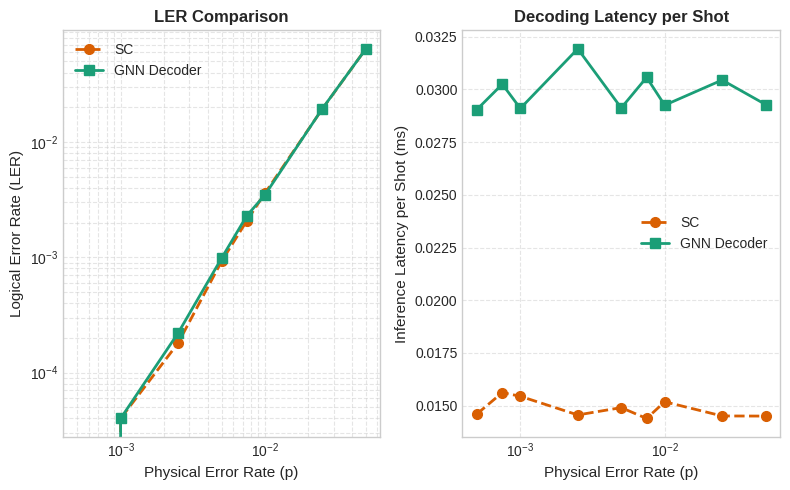

In [88]:
n = 3
lstate = "z"
csv_filename = f"qpc_decoder_benchmark_n{n}_{lstate}.csv"
fig_filename = f"qpc_decoder_benchmark_n{n}_{lstate}.png"

# Step 2: Generate visual plots from CSV data
plot_qpc_benchmark_results(
    csv_filename=csv_filename,
    save_fig_path=fig_filename
)

## Resume prediction

In [152]:
import os
import random
import time
from collections import Counter
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import precision_score, recall_score, f1_score
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

def append_record_to_csv(record_dict, csv_filename):
    df = pd.DataFrame([record_dict])
    file_exists = os.path.exists(csv_filename)
    df.to_csv(csv_filename, mode='a', header=not file_exists, index=False)

def get_completed_p_rates(csv_filename, target_errors):
    """
    Reads existing CSV and returns a set of p_error values that have already 
    reached target_errors or hit the target completion flag.
    """
    if not os.path.exists(csv_filename):
        return set()
    
    try:
        df = pd.read_csv(csv_filename)
        if df.empty:
            return set()
        
        completed_p = set()
        
        # Group by p_error and check if any row reached target_errors_reached
        for p_val, group in df.groupby("p_error"):
            # Check if target errors reached OR max error threshold satisfied
            if "target_errors_reached" in group.columns and group["target_errors_reached"].any():
                completed_p.add(p_val)
            else:
                # Fallback check on raw error counts
                max_gnn_err = group["gnn_error_events"].max() if "gnn_error_events" in group.columns else 0
                max_trad_err = group["traditional_error_events"].max() if "traditional_error_events" in group.columns else 0
                if max_gnn_err >= target_errors and max_trad_err >= target_errors:
                    completed_p.add(p_val)
                    
        return completed_p
    except Exception as e:
        print(f"Warning: Could not parse existing CSV '{csv_filename}': {e}")
        return set()


def run_error_sweep_and_export_csv(
    n, i, lstate, sim_type, model_file_path,
    p_rates=[0.0005, 0.00075, 0.001, 0.0025, 0.005, 0.0075, 0.01, 0.025, 0.05],
    target_errors=100,
    chunk_size=100000,
    max_shots_per_p=10000000,
    checkpoint_interval=1000000,
    csv_filename="qpc_decoder_benchmark_results.csv"
):
    N = 2**n
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = EnhancedQPCGNN(in_channels=5, hidden_dim=256, num_layers=4, heads=4).to(device)
    model.load_state_dict(torch.load(model_file_path, map_location=device))
    model.eval()

    zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
    zpos_list[n] = i - 1

    criterion = torch.nn.BCEWithLogitsLoss()

    # ---------------------------------------------------------
    # Auto-detect completed p_error values from CSV
    # ---------------------------------------------------------
    completed_p_rates = get_completed_p_rates(csv_filename, target_errors)
    if completed_p_rates:
        print(f"[AUTO-RESUME] Found existing completed p_error rates in '{csv_filename}':")
        for cp in sorted(completed_p_rates):
            print(f"  - p = {cp} (Already finished)")

    for p_error in p_rates:
        # Check if this error rate is already finished in the CSV
        if p_error in completed_p_rates:
            print(f"\n--> Skipping p_error = {p_error} (Already completed in CSV).")
            continue

        print(f"\n=======================================================")
        print(f"--> Starting Benchmark for p_error = {p_error}")
        print(f"    Target Errors: {target_errors} | Chunk Size: {chunk_size:,}")
        print(f"=======================================================")

        total_raw_shots = 0
        total_accepted_shots = 0
        total_trad_errors = 0
        total_gnn_errors = 0
        
        total_trad_time = 0.0
        total_gnn_time = 0.0
        total_gnn_loss = 0.0

        all_targets = []
        all_gnn_preds = []

        last_checkpoint_shot = 0

        while True:
            seed = random.randint(1, 999999999)
            np.random.seed(seed)
            torch.manual_seed(seed)
            random.seed(seed)

            zpos, target_idx = get_zpos_and_target_from_i(i, lstate)
            edge_index = build_polar_butterfly_edge_index(n)

            # 1. Sample Stim chunk
            raw_shots = sample_stim_generation(n, i, lstate, sim_type, p_error, chunk_size, seed)
            validation_counts = dict(Counter(raw_shots))
            total_raw_shots += chunk_size

            # 2. Traditional Decoder Benchmark
            count_accept_p, count_logerror_trad, count_undecided, sr_p, detect_normal, decoding_normal = (
                get_logical_error_on_accepted_states(n, lstate.upper(), validation_counts, zpos_list=zpos_list)
            )
            total_trad_errors += count_logerror_trad
            total_trad_time += decoding_normal

            # 3. Construct Graphs
            graphs_list = []
            for shot_str in raw_shots:
                meas = np.array([ord(c) - ord('0') for c in shot_str], dtype=int)
                aux_meas = meas[:N-1:-1]
                data_meas = meas[N-1::-1]

                success, qstate_UV = q1prep(n, zpos, aux_meas)
                if success == 0:
                    continue

                logical_bit = random.choice([0, 1])

                if lstate.upper() == "Z":
                    qstate_U = np.zeros((N,), dtype=int)
                    qstate_U[:zpos] = qstate_UV[:zpos]
                    qstate_U[zpos] = logical_bit
                    codec.polarenc(qstate_U)
                    delta_data = np.mod(data_meas + qstate_U, 2)
                    true_bit = int(np.mod(qstate_UV[zpos] + logical_bit, 2))
                else:
                    qstate_V = np.zeros((N,), dtype=int)
                    qstate_V[zpos+2:] = qstate_UV[zpos+2:]
                    qstate_V[zpos+1] = logical_bit
                    codec.revpolarenc(qstate_V)
                    delta_data = np.mod(data_meas + qstate_V, 2)
                    true_bit = int(np.mod(qstate_UV[zpos+1] + logical_bit, 2))

                node_features, _ = build_5channel_node_features(delta_data, i, lstate, n, p_error)
                x = torch.tensor(node_features, dtype=torch.float32)
                y = torch.tensor([true_bit], dtype=torch.float32)
                graphs_list.append(Data(x=x, edge_index=edge_index, y=y))

            chunk_accepted_count = len(graphs_list)
            total_accepted_shots += chunk_accepted_count

            # 4. GNN Inference
            if chunk_accepted_count > 0:
                test_loader = DataLoader(graphs_list, batch_size=512, shuffle=False)
                
                if device == "cuda":
                    torch.cuda.synchronize()
                t_gnn_start = time.perf_counter()

                with torch.no_grad():
                    for batch in test_loader:
                        batch = batch.to(device)
                        logits = model(batch.x, batch.edge_index, batch.batch)
                        targets = batch.y.squeeze(-1) if batch.y.dim() > 1 else batch.y

                        loss = criterion(logits, targets)
                        num_graphs = batch.num_graphs if hasattr(batch, 'num_graphs') else len(targets)
                        total_gnn_loss += loss.item() * num_graphs

                        preds = (logits >= 0.0).float()
                        targets_np = targets.cpu().numpy()
                        preds_np = preds.cpu().numpy()

                        total_gnn_errors += np.sum(preds_np != targets_np)
                        all_targets.extend(targets_np)
                        all_gnn_preds.extend(preds_np)

                if device == "cuda":
                    torch.cuda.synchronize()
                total_gnn_time += (time.perf_counter() - t_gnn_start)

            # 5. Status Logging
            trad_ler = total_trad_errors / total_accepted_shots if total_accepted_shots > 0 else 0.0
            gnn_ler = total_gnn_errors / total_accepted_shots if total_accepted_shots > 0 else 0.0

            print(
                f"[Shots: {total_raw_shots:,} | Accepted: {total_accepted_shots:,}] "
                f"GNN Errors: {total_gnn_errors}/{target_errors} (LER: {gnn_ler:.4e}) | "
                f"Trad Errors: {total_trad_errors}/{target_errors} (LER: {trad_ler:.4e})"
            )

            reached_target = (total_gnn_errors >= target_errors and total_trad_errors >= target_errors)
            reached_max_shots = (total_raw_shots >= max_shots_per_p)
            checkpoint_due = (total_raw_shots - last_checkpoint_shot >= checkpoint_interval)

            if reached_target or reached_max_shots or checkpoint_due:
                last_checkpoint_shot = total_raw_shots
                
                acc = 1.0 - gnn_ler
                prec = precision_score(all_targets, all_gnn_preds, zero_division=0)
                rec = recall_score(all_targets, all_gnn_preds, zero_division=0)
                f1 = f1_score(all_targets, all_gnn_preds, zero_division=0)
                avg_gnn_loss = total_gnn_loss / total_accepted_shots if total_accepted_shots > 0 else 0.0

                record = {
                    "p_error": p_error,
                    "total_raw_shots": total_raw_shots,
                    "accepted_shots": total_accepted_shots,
                    "acceptance_rate": total_accepted_shots / total_raw_shots if total_raw_shots > 0 else 0.0,
                    
                    "gnn_error_events": int(total_gnn_errors),
                    "traditional_error_events": int(total_trad_errors),
                    "target_errors_reached": reached_target,
                    
                    "traditional_LER": trad_ler,
                    "gnn_LER": gnn_ler,
                    "traditional_fidelity": 1.0 - trad_ler,
                    "gnn_fidelity": acc,
                    "gnn_precision": prec,
                    "gnn_recall": rec,
                    "gnn_f1_score": f1,
                    "gnn_loss": avg_gnn_loss,
                    
                    "traditional_time_sec": total_trad_time,
                    "gnn_time_sec": total_gnn_time,
                    "traditional_ms_per_shot": (total_trad_time / total_accepted_shots) * 1000 if total_accepted_shots > 0 else 0.0,
                    "gnn_ms_per_shot": (total_gnn_time / total_accepted_shots) * 1000 if total_accepted_shots > 0 else 0.0
                }

                append_record_to_csv(record, csv_filename)
                print(f"--> [CHECKPOINT] Progress appended to '{csv_filename}'")

            if reached_target or reached_max_shots:
                reason = "Reached Target Errors" if reached_target else "Reached Max Safety Shot Cap"
                print(f"--> Completed p_error = {p_error} ({reason}).\n")
                break

    print(f"\n[FINISHED ALL SWEEPS] Full results continuously saved in '{csv_filename}'.\n")

In [153]:
# --- Experiment Configuration ---
n = 3
i = 4
lstate = "x"  # Change to "z" when running for Z state
sim_type = "m1"
max_samples = 10000000
model_file_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_200.pt"

p_error_sweep = [0.0005, 0.00075, 0.001, 0.0025, 0.005, 0.0075, 0.01, 0.025, 0.05]
csv_filename = f"qpc_decoder_benchmark_n{n}_{lstate}.csv"
fig_filename = f"qpc_decoder_benchmark_n{n}_{lstate}.png"

run_error_sweep_and_export_csv(
    n=n, i=i, lstate=lstate, sim_type=sim_type,
    model_file_path=model_file_path,
    p_rates=p_error_sweep,
    target_errors=2000,
    chunk_size=200000,           # Larger chunk size speeds up low p_error simulation
    max_shots_per_p=20000000,    # Higher safety cap for 0.0005 / 0.00075
    checkpoint_interval=1000000,
    csv_filename=csv_filename
)


--> Starting Benchmark for p_error = 0.0005
    Target Errors: 2000 | Chunk Size: 200,000
[Shots: 200,000 | Accepted: 195,846] GNN Errors: 903/2000 (LER: 4.6108e-03) | Trad Errors: 897/2000 (LER: 4.5801e-03)
[Shots: 400,000 | Accepted: 391,704] GNN Errors: 1823/2000 (LER: 4.6540e-03) | Trad Errors: 1795/2000 (LER: 4.5825e-03)
[Shots: 600,000 | Accepted: 587,662] GNN Errors: 2700/2000 (LER: 4.5945e-03) | Trad Errors: 2652/2000 (LER: 4.5128e-03)
--> [CHECKPOINT] Progress appended to 'qpc_decoder_benchmark_n3_x.csv'
--> Completed p_error = 0.0005 (Reached Target Errors).


--> Starting Benchmark for p_error = 0.00075
    Target Errors: 2000 | Chunk Size: 200,000
[Shots: 200,000 | Accepted: 193,804] GNN Errors: 1371/2000 (LER: 7.0742e-03) | Trad Errors: 1338/2000 (LER: 6.9039e-03)
[Shots: 400,000 | Accepted: 387,524] GNN Errors: 2711/2000 (LER: 6.9957e-03) | Trad Errors: 2669/2000 (LER: 6.8873e-03)
--> [CHECKPOINT] Progress appended to 'qpc_decoder_benchmark_n3_x.csv'
--> Completed p_erro

In [ ]:
# --- Experiment Configuration ---
n = 3
i = 4
lstate = "z"  # Change to "z" when running for Z state
sim_type = "m1"
max_samples = 10000000
model_file_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_200.pt"

p_error_sweep = [0.0005, 0.00075, 0.001, 0.0025, 0.005, 0.0075, 0.01, 0.025, 0.05]
csv_filename = f"qpc_decoder_benchmark_n{n}_{lstate}.csv"
fig_filename = f"qpc_decoder_benchmark_n{n}_{lstate}.png"

run_error_sweep_and_export_csv(
    n=n, i=i, lstate=lstate, sim_type=sim_type,
    model_file_path=model_file_path,
    p_rates=p_error_sweep,
    target_errors=2000,
    chunk_size=200000,           # Larger chunk size speeds up low p_error simulation
    max_shots_per_p=20000000,    # Higher safety cap for 0.0005 / 0.00075
    checkpoint_interval=1000000,
    csv_filename=csv_filename
)


--> Starting Benchmark for p_error = 0.0005
    Target Errors: 2000 | Chunk Size: 200,000
[Shots: 200,000 | Accepted: 200,000] GNN Errors: 1/2000 (LER: 5.0000e-06) | Trad Errors: 2/2000 (LER: 1.0000e-05)
[Shots: 400,000 | Accepted: 400,000] GNN Errors: 6/2000 (LER: 1.5000e-05) | Trad Errors: 6/2000 (LER: 1.5000e-05)
[Shots: 600,000 | Accepted: 600,000] GNN Errors: 9/2000 (LER: 1.5000e-05) | Trad Errors: 8/2000 (LER: 1.3333e-05)
[Shots: 800,000 | Accepted: 800,000] GNN Errors: 10/2000 (LER: 1.2500e-05) | Trad Errors: 9/2000 (LER: 1.1250e-05)
[Shots: 1,000,000 | Accepted: 1,000,000] GNN Errors: 13/2000 (LER: 1.3000e-05) | Trad Errors: 12/2000 (LER: 1.2000e-05)
--> [CHECKPOINT] Progress appended to 'qpc_decoder_benchmark_n3_z.csv'
[Shots: 1,200,000 | Accepted: 1,200,000] GNN Errors: 15/2000 (LER: 1.2500e-05) | Trad Errors: 14/2000 (LER: 1.1667e-05)
[Shots: 1,400,000 | Accepted: 1,400,000] GNN Errors: 15/2000 (LER: 1.0714e-05) | Trad Errors: 15/2000 (LER: 1.0714e-05)
[Shots: 1,600,000 | A

In [ ]:
# --- Experiment Configuration ---
n = 3
i = 4
lstate = "x"  # Change to "z" when running for Z state
sim_type = "m1"
max_samples = 10000000
model_file_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_200.pt"

p_error_sweep = [0.0005, 0.00075, 0.001, 0.0025, 0.005, 0.0075, 0.01, 0.025, 0.05]
csv_filename = f"qpc_decoder_benchmark_n{n}_{lstate}.csv"
fig_filename = f"qpc_decoder_benchmark_n{n}_{lstate}.png"

run_error_sweep_and_export_csv(
    n=n, i=i, lstate=lstate, sim_type=sim_type,
    model_file_path=model_file_path,
    p_rates=p_error_sweep,
    target_errors=2000,
    chunk_size=200000,           # Larger chunk size speeds up low p_error simulation
    max_shots_per_p=20000000,    # Higher safety cap for 0.0005 / 0.00075
    checkpoint_interval=1000000,
    csv_filename=csv_filename
)

## Resume and train GNN

In [132]:
import time
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import f1_score, precision_score, recall_score
from torch_geometric.loader import DataLoader

def resume_and_train_gnn(
    checkpoint_path,
    train_loader,
    val_loader,
    start_epoch=101,
    additional_epochs=100,
    initial_lr=5e-4,
    device="cuda",
    save_path="best_qpc_gnn_model_enhanced_phase2.pt",
    history_csv_path="training_history_phase2.csv"
):
    """
    Resumes training of the GNN decoder, tracks detailed timing & performance metrics,
    and continuously exports training history to CSV.
    """
    # 1. Instantiate identical model architecture
    model = EnhancedQPCGNN(in_channels=5, hidden_dim=256, num_layers=4, heads=4).to(device)

    # 2. Load the trained state dict from Phase 1 (Epoch 100)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"Loaded weights from '{checkpoint_path}'. Resuming fine-tuning...")

    # 3. Initialize Optimizer with lower LR for fine-tuning
    optimizer = torch.optim.AdamW(model.parameters(), lr=initial_lr, weight_decay=1e-4)

    # 4. Smooth Cosine Annealing Scheduler down to 1e-6
    total_epochs = start_epoch + additional_epochs - 1
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=additional_epochs, eta_min=1e-6
    )

    criterion = torch.nn.BCEWithLogitsLoss()
    best_val_loss = float("inf")
    history_list = []

    print(f"Starting fine-tuning: Epochs {start_epoch} -> {total_epochs}")
    print("-" * 110)

    for epoch in range(start_epoch, total_epochs + 1):
        # -------------------------------------------------------------
        # Training Phase
        # -------------------------------------------------------------
        model.train()
        train_loss = 0.0
        total_train_samples = 0
        
        if device == "cuda":
            torch.cuda.synchronize()
        t_train_start = time.perf_counter()

        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()

            logits = model(batch.x, batch.edge_index, batch.batch)
            targets = batch.y.squeeze(-1) if batch.y.dim() > 1 else batch.y

            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            num_graphs = batch.num_graphs if hasattr(batch, 'num_graphs') else len(targets)
            train_loss += loss.item() * num_graphs
            total_train_samples += num_graphs

        if device == "cuda":
            torch.cuda.synchronize()
        train_time_sec = time.perf_counter() - t_train_start
        avg_train_loss = train_loss / total_train_samples if total_train_samples > 0 else 0.0
        train_throughput = total_train_samples / train_time_sec if train_time_sec > 0 else 0.0

        # -------------------------------------------------------------
        # Validation Phase
        # -------------------------------------------------------------
        model.eval()
        val_loss = 0.0
        correct = 0
        total_val_samples = 0
        all_targets = []
        all_preds = []

        if device == "cuda":
            torch.cuda.synchronize()
        t_val_start = time.perf_counter()

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                logits = model(batch.x, batch.edge_index, batch.batch)
                targets = batch.y.squeeze(-1) if batch.y.dim() > 1 else batch.y

                loss = criterion(logits, targets)
                num_graphs = batch.num_graphs if hasattr(batch, 'num_graphs') else len(targets)
                val_loss += loss.item() * num_graphs

                preds = (logits >= 0.0).float()
                correct += (preds == targets).sum().item()
                total_val_samples += num_graphs

                all_targets.extend(targets.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

        if device == "cuda":
            torch.cuda.synchronize()
        val_time_sec = time.perf_counter() - t_val_start

        avg_val_loss = val_loss / total_val_samples if total_val_samples > 0 else 0.0
        val_acc = correct / total_val_samples if total_val_samples > 0 else 0.0
        val_ler = 1.0 - val_acc
        val_f1 = f1_score(all_targets, all_preds, zero_division=0)
        
        current_lr = scheduler.get_last_lr()[0]
        scheduler.step()

        # -------------------------------------------------------------
        # Checkpoint Saving & Logging
        # -------------------------------------------------------------
        saved_str = ""
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            saved_str = " -> Best Model Saved!"

        total_epoch_time = train_time_sec + val_time_sec

        # Collect record for current epoch
        epoch_record = {
            "epoch": epoch,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_accuracy": val_acc,
            "val_LER": val_ler,
            "val_f1_score": val_f1,
            "learning_rate": current_lr,
            "train_time_sec": train_time_sec,
            "val_time_sec": val_time_sec,
            "total_epoch_time_sec": total_epoch_time,
            "train_throughput_samples_per_sec": train_throughput,
            "train_samples": total_train_samples,
            "val_samples": total_val_samples
        }
        history_list.append(epoch_record)

        # Save continuous CSV update (prevents data loss if interrupted)
        df_history = pd.DataFrame(history_list)
        df_history.to_csv(history_csv_path, index=False)

        print(
            f"Epoch {epoch:03d}/{total_epochs:03d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc * 100:.2f}% (LER: {val_ler:.4e}) | "
            f"F1: {val_f1:.4f} | "
            f"Time: {total_epoch_time:.1f}s | "
            f"LR: {current_lr:.1e}{saved_str}"
        )

    print("-" * 110)
    print(f"Training completed successfully.")
    print(f"Metrics log saved to '{history_csv_path}'")
    print(f"Best model weights saved to '{save_path}'")

    return df_history

In [133]:
# 1. Train Dataset Generator (e.g., 80% = 8,000 samples)
max_samples = 1000000
max_samples_train = max_samples
max_samples_val = int(0.2 * max_samples)

lstate = "x"
n=3
N=2**n
i=4
sim_type = "m1"
# mapping_option="option_1"
p_min = 0.001
p_max = 0.05
seed_train = random.randint(1, 9999999)
seed_val = random.randint(1, 9999999)
current_epochs = 100
target_epochs = 200
learning_rate = 2e-3
# save_path = f"best_qpc_gnn_model_n{n}_{lstate}_{sim_type}_{epochs}.pt"


train_dataset = StreamingQPCDataset(
    n=n,
    i=i,
    lstate=lstate,
    sim_type=sim_type,
    codec=codec, 
    q1prep_func=q1prep, 
    stim_sampler_func=sample_stim_generation,
    p_min=p_min, 
    p_max=p_max,
    max_samples=max_samples_train,
    stim_chunk_size=500,     # Small chunks = frequent p_error updates
    buffer_size=10000,       # Holds samples from ~20 distinct noise rates simultaneously
    seed=seed_train
)


# 2. Validation Dataset Generator (e.g., 20% = 2,000 samples, different seed)
val_dataset = StreamingQPCDataset(
    n=n,
    i=i,
    lstate=lstate,
    sim_type=sim_type,
    codec=codec, 
    q1prep_func=q1prep, 
    stim_sampler_func=sample_stim_generation,
    p_min=p_min, 
    p_max=p_max,
    max_samples=max_samples_val,
    stim_chunk_size=500,     # Small chunks = frequent p_error updates
    buffer_size=10000,       # Holds samples from ~20 distinct noise rates simultaneously
    seed=seed_val
)

# 2. Materialize streaming dataset into RAM as a list
train_graphs = list(train_dataset)  # Compact syntax for iterating into list
train_graphs = list(val_dataset)  # Compact syntax for iterating into list


# 3. Create DataLoader directly on the RAM list
train_loader = DataLoader(
    train_graphs,
    batch_size=2048,
    shuffle=True,       # Full epoch shuffling enabled
    pin_memory=True,    # Async transfer to CUDA GPU
    num_workers=0       # 0 is fastest for in-memory PyG lists
)

# 3. Create DataLoader directly on the RAM list
val_loader = DataLoader(
    train_graphs,
    batch_size=2048,
    shuffle=True,       # Full epoch shuffling enabled
    pin_memory=True,    # Async transfer to CUDA GPU
    num_workers=0       # 0 is fastest for in-memory PyG lists
)

In [134]:
# =====================================================================
# Execution
# =====================================================================
load_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_{current_epochs}.pt"
save_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_{target_epochs}.pt"

history_csv_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_{target_epochs}.csv"

# Run fine-tuning and obtain training metrics dataframe
df_history = resume_and_train_gnn(
    checkpoint_path=load_path,
    train_loader=train_loader,
    val_loader=val_loader,
    start_epoch=101,
    additional_epochs=100,
    initial_lr=2e-4,  # Recommended fine-tuning LR
    save_path=save_path,
    history_csv_path=history_csv_path
)

Loaded weights from 'best_qpc_gnn_model_enhanced_n3_x_m1_100.pt'. Resuming fine-tuning...
Starting fine-tuning: Epochs 101 -> 200
--------------------------------------------------------------------------------------------------------------
Epoch 101/200 | Train Loss: 0.3083 | Val Loss: 0.3056 | Val Acc: 82.31% (LER: 1.7688e-01) | F1: 0.8164 | Time: 19.9s | LR: 2.0e-04 -> Best Model Saved!
Epoch 102/200 | Train Loss: 0.3065 | Val Loss: 0.3051 | Val Acc: 82.56% (LER: 1.7439e-01) | F1: 0.8200 | Time: 19.4s | LR: 2.0e-04 -> Best Model Saved!
Epoch 103/200 | Train Loss: 0.3059 | Val Loss: 0.3051 | Val Acc: 82.60% (LER: 1.7402e-01) | F1: 0.8211 | Time: 19.3s | LR: 2.0e-04
Epoch 104/200 | Train Loss: 0.3059 | Val Loss: 0.3043 | Val Acc: 82.62% (LER: 1.7376e-01) | F1: 0.8223 | Time: 19.4s | LR: 2.0e-04 -> Best Model Saved!
Epoch 105/200 | Train Loss: 0.3058 | Val Loss: 0.3045 | Val Acc: 82.65% (LER: 1.7352e-01) | F1: 0.8202 | Time: 19.8s | LR: 2.0e-04
Epoch 106/200 | Train Loss: 0.3055 | Val 

In [135]:
# 1. Train Dataset Generator (e.g., 80% = 8,000 samples)
max_samples = 1000000
max_samples_train = max_samples
max_samples_val = int(0.2 * max_samples)

lstate = "z"
n=3
N=2**n
i=4
sim_type = "m1"
# mapping_option="option_1"
p_min = 0.001
p_max = 0.05
seed_train = random.randint(1, 9999999)
seed_val = random.randint(1, 9999999)
current_epochs = 100
target_epochs = 200
learning_rate = 2e-3
# save_path = f"best_qpc_gnn_model_n{n}_{lstate}_{sim_type}_{epochs}.pt"


train_dataset = StreamingQPCDataset(
    n=n,
    i=i,
    lstate=lstate,
    sim_type=sim_type,
    codec=codec, 
    q1prep_func=q1prep, 
    stim_sampler_func=sample_stim_generation,
    p_min=p_min, 
    p_max=p_max,
    max_samples=max_samples_train,
    stim_chunk_size=500,     # Small chunks = frequent p_error updates
    buffer_size=10000,       # Holds samples from ~20 distinct noise rates simultaneously
    seed=seed_train
)


# 2. Validation Dataset Generator (e.g., 20% = 2,000 samples, different seed)
val_dataset = StreamingQPCDataset(
    n=n,
    i=i,
    lstate=lstate,
    sim_type=sim_type,
    codec=codec, 
    q1prep_func=q1prep, 
    stim_sampler_func=sample_stim_generation,
    p_min=p_min, 
    p_max=p_max,
    max_samples=max_samples_val,
    stim_chunk_size=500,     # Small chunks = frequent p_error updates
    buffer_size=10000,       # Holds samples from ~20 distinct noise rates simultaneously
    seed=seed_val
)

# 2. Materialize streaming dataset into RAM as a list
train_graphs = list(train_dataset)  # Compact syntax for iterating into list
train_graphs = list(val_dataset)  # Compact syntax for iterating into list


# 3. Create DataLoader directly on the RAM list
train_loader = DataLoader(
    train_graphs,
    batch_size=2048,
    shuffle=True,       # Full epoch shuffling enabled
    pin_memory=True,    # Async transfer to CUDA GPU
    num_workers=0       # 0 is fastest for in-memory PyG lists
)

# 3. Create DataLoader directly on the RAM list
val_loader = DataLoader(
    train_graphs,
    batch_size=2048,
    shuffle=True,       # Full epoch shuffling enabled
    pin_memory=True,    # Async transfer to CUDA GPU
    num_workers=0       # 0 is fastest for in-memory PyG lists
)

In [136]:
# =====================================================================
# Execution
# =====================================================================
load_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_{current_epochs}.pt"
save_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_{target_epochs}.pt"

history_csv_path = f"best_qpc_gnn_model_enhanced_n{n}_{lstate}_{sim_type}_{target_epochs}.csv"

# Run fine-tuning and obtain training metrics dataframe
df_history = resume_and_train_gnn(
    checkpoint_path=load_path,
    train_loader=train_loader,
    val_loader=val_loader,
    start_epoch=101,
    additional_epochs=100,
    initial_lr=2e-4,  # Recommended fine-tuning LR
    save_path=save_path,
    history_csv_path=history_csv_path
)

Loaded weights from 'best_qpc_gnn_model_enhanced_n3_z_m1_100.pt'. Resuming fine-tuning...
Starting fine-tuning: Epochs 101 -> 200
--------------------------------------------------------------------------------------------------------------
Epoch 101/200 | Train Loss: 0.0514 | Val Loss: 0.0489 | Val Acc: 97.58% (LER: 2.4229e-02) | F1: 0.9758 | Time: 19.3s | LR: 2.0e-04 -> Best Model Saved!
Epoch 102/200 | Train Loss: 0.0496 | Val Loss: 0.0484 | Val Acc: 97.61% (LER: 2.3905e-02) | F1: 0.9762 | Time: 19.3s | LR: 2.0e-04 -> Best Model Saved!
Epoch 103/200 | Train Loss: 0.0492 | Val Loss: 0.0482 | Val Acc: 97.62% (LER: 2.3786e-02) | F1: 0.9763 | Time: 19.3s | LR: 2.0e-04 -> Best Model Saved!
Epoch 104/200 | Train Loss: 0.0490 | Val Loss: 0.0484 | Val Acc: 97.62% (LER: 2.3843e-02) | F1: 0.9764 | Time: 19.3s | LR: 2.0e-04
Epoch 105/200 | Train Loss: 0.0489 | Val Loss: 0.0480 | Val Acc: 97.65% (LER: 2.3476e-02) | F1: 0.9767 | Time: 19.3s | LR: 2.0e-04 -> Best Model Saved!
Epoch 106/200 | Trai

# Transfer Learning for n=5

In [ ]:


device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Instantiate n=4 (N=16) Test Streaming Dataset
test_dataset_n4 = StreamingQPCDataset(
    n=4,                          # N = 16
    sim_type="m1",
    codec=codec, 
    q1prep_func=q1prep, 
    stim_sampler_func=sample_stim_generation,
    mapping_option="option_1",    # Option 1 automatically uses target_idx = 6 for n=4
    p_min=0.005, 
    p_max=0.005,
    max_samples=50000,
    batch_size=10000,
    seed=88888
)

test_loader_n4 = DataLoader(test_dataset_n4, batch_size=512)

# 2. Load the exact model trained on n=3
model = QPC_GNN_Decoder(in_channels=5, hidden_dim=64, num_layers=3, heads=4)
model.load_state_dict(torch.load("best_qpc_gnn_model.pt"))  # Saved from n=3 training

# 3. Evaluate Zero-Shot Transfer on n=4
zero_shot_metrics = evaluate_gnn_metrics(model, test_loader_n4, device=device)

print("\n" + "=" * 50)
print("      ZERO-SHOT TRANSFER RESULTS (n=4 / N=16)")
print("=" * 50)
print(f"Zero-Shot Test Loss:      {zero_shot_metrics['test_loss']:.4f}")
print(f"Zero-Shot State Fidelity: {zero_shot_metrics['fidelity'] * 100:.2f}%")
print(f"Zero-Shot LER:            {zero_shot_metrics['LER']:.6f}")
print("=" * 50)


      ZERO-SHOT TRANSFER RESULTS (n=4 / N=16)
Zero-Shot Test Loss:      0.0000
Zero-Shot State Fidelity: 100.00%
Zero-Shot LER:            0.000000


In [ ]:
# 1. Prepare n=4 Training and Validation Streams
train_dataset_n4 = StreamingQPCDataset(
    n=4, sim_type="m1", codec=codec, q1prep_func=q1prep,
    stim_sampler_func=sample_stim_generation, mapping_option="option_1",
    p_min=0.001, p_max=0.05, max_samples=150000, batch_size=50000, seed=52345
)

val_dataset_n4 = StreamingQPCDataset(
    n=4, sim_type="m1", codec=codec, q1prep_func=q1prep,
    stim_sampler_func=sample_stim_generation, mapping_option="option_1",
    p_min=0.001, p_max=0.05, max_samples=50000, batch_size=10000, seed=54326
)

train_loader_n4 = DataLoader(train_dataset_n4, batch_size=512)
val_loader_n4 = DataLoader(val_dataset_n4, batch_size=512)

# 2. Load Pretrained n=3 Weights
model = QPC_GNN_Decoder(in_channels=5, hidden_dim=64, num_layers=3, heads=4)
model.load_state_dict(torch.load("best_qpc_gnn_model.pt"))

# 3. Fine-Tune with Lower Learning Rate (lr=1e-4)
finetune_history = train_qpc_gnn(
    model=model,
    train_loader=train_loader_n4,
    val_loader=val_loader_n4,
    epochs=5,                  # Only 3-5 epochs needed for transfer learning
    lr=1e-4,                   # 10x smaller LR to preserve learned representations
    device=device,
    save_path="best_qpc_gnn_model_n4.pt"
)

Starting QPC GNN Training on CPU...
Epoch 001/005 | Train Loss: 0.0000 | Val Loss: 0.0000 | Val Acc: 100.00% | LR: 1.0e-04 -> Checkpoint Saved!
Epoch 002/005 | Train Loss: 0.0000 | Val Loss: 0.0000 | Val Acc: 100.00% | LR: 1.0e-04
Epoch 003/005 | Train Loss: 0.0000 | Val Loss: 0.0000 | Val Acc: 100.00% | LR: 1.0e-04
Epoch 004/005 | Train Loss: 0.0000 | Val Loss: 0.0000 | Val Acc: 100.00% | LR: 1.0e-04
Epoch 005/005 | Train Loss: 0.0000 | Val Loss: 0.0000 | Val Acc: 100.00% | LR: 5.0e-05

Training Complete! Best model saved to 'best_qpc_gnn_model_n4.pt'.


In [ ]:
from collections import Counter
import numpy as np
import torch
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data

# 1. Setup Parameters
n = 4
N = 2**n
lstate = "x"           # State to evaluate
p_error = 0.005        # Physical error rate point
max_samples = 100000   # Total raw shots budget
mapping_option = "option_1"
zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
sim_type = "m1"
batch_size = 100000
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seeds for reproducible noise sampling
seed = 99999
np.random.seed(seed)
torch.manual_seed(seed)

# ---------------------------------------------------------------------
# 2. Generate Raw Shots & Format for Both Decoders
# ---------------------------------------------------------------------
print(f"Sampling {max_samples} raw Stim shots at p = {p_error} for LSTATE = '{lstate.upper()}'...")

# Generate raw measurement strings using your Stim generator
# raw_shots = sample_stim_generation(
#     batch_size=max_samples, 
#     p_error=p_error, 
#     lstate=lstate
# )

target_idx = get_info_target_index(n, lstate, option=mapping_option)
zpos = convert_i_to_zpos(target_idx, n, lstate.lower())

# print(target_idx, zpos)
edge_index = build_polar_butterfly_edge_index(n)

raw_shots = sample_stim_generation(n, target_idx, lstate, sim_type, p_error, batch_size, seed)

# A) Format for Traditional Decoder: Convert raw shots list to counts dict
validation_counts = dict(Counter(raw_shots))

# B) Format for GNN Decoder: Convert the EXACT SAME raw shots to PyG graphs
graphs_list = []



for shot_str in raw_shots:
    meas = np.array([ord(c) - ord('0') for c in shot_str], dtype=int)
    aux_meas = meas[:N-1:-1]
    data_meas = meas[N-1::-1]

    # Stage 1: Prep Verification
    success, qstate_UV = q1prep(n, zpos, aux_meas)
    if success == 0:
        continue  # Filter out unaccepted states

    # Frame tracking & XOR syndrome computation
    if lstate.upper() == "Z":
        qstate_U = np.zeros((N,), dtype=int)
        qstate_U[:zpos] = qstate_UV[:zpos]
        codec.polarenc(qstate_U)
        delta_data = np.mod(data_meas + qstate_U, 2)
        true_bit = qstate_UV[zpos]
    else:
        qstate_V = np.zeros((N,), dtype=int)
        qstate_V[zpos+2:] = qstate_UV[zpos+2:]
        codec.revpolarenc(qstate_V)
        delta_data = np.mod(data_meas + qstate_V, 2)
        true_bit = qstate_UV[zpos+1]

    # Construct 5-channel feature graph
    node_features, _ = build_5channel_node_features(
        delta_data, N, lstate, n, p_error, mapping_option
    )

    x = torch.tensor(node_features, dtype=torch.float32)
    y = torch.tensor([true_bit], dtype=torch.float32)
    graphs_list.append(Data(x=x, edge_index=edge_index, y=y))

test_loader = DataLoader(graphs_list, batch_size=512, shuffle=False)

# ---------------------------------------------------------------------
# 3. Evaluate Method 1: Traditional Decoder Function
# ---------------------------------------------------------------------
# print(n, target_idx, lstate.upper(), zpos_list)
# print(validation_counts)

count_accept_p, count_logerror, count_undecided, sr_p, detect_normal, decoding_normal = (
    get_logical_error_on_accepted_states(n, lstate.upper(), validation_counts, zpos_list=zpos_list)
)

# ---------------------------------------------------------------------
# 4. Evaluate Method 2: Trained GNN Decoder
# ---------------------------------------------------------------------
# Load best trained model weights
model = QPC_GNN_Decoder(in_channels=5, hidden_dim=64, num_layers=3, heads=4)
model.load_state_dict(torch.load("best_qpc_gnn_model_n4.pt"))

# Run inference on test_loader using your evaluate_gnn_metrics function
gnn_metrics = evaluate_gnn_metrics(model, test_loader, device=device)

# ---------------------------------------------------------------------
# 5. Output Comparative Results
# ---------------------------------------------------------------------
print("\n" + "=" * 60)
print(f"      QUANTUM DECODER BENCHMARK (N={N}, p={p_error}, State={lstate.upper()})")
print("=" * 60)
print(f"Total Raw Shots Sampled:         {max_samples}")
print(f"Accepted Shots (Baseline):       {count_accept_p}")
print(f"Accepted Shots (GNN Dataset):    {gnn_metrics['total_evaluated_shots']}")
print("-" * 60)
print(f"Traditional Decoder LER:         {1-sr_p:.6f}")
print(f"GNN Decoder LER:                 {gnn_metrics['LER']:.6f}")
print("-" * 60)
print(f"Traditional Success Rate:        {(sr_p) * 100:.2f}%")
print(f"GNN Decoder State Fidelity:       {gnn_metrics['fidelity'] * 100:.2f}%")
print(f"GNN F1-Score:                    {gnn_metrics['f1_score']:.4f}")
print("=" * 60)

Sampling 100000 raw Stim shots at p = 0.005 for LSTATE = 'X'...

      QUANTUM DECODER BENCHMARK (N=16, p=0.005, State=X)
Total Raw Shots Sampled:         100000
Accepted Shots (Baseline):       15010
Accepted Shots (GNN Dataset):    54989
------------------------------------------------------------
Traditional Decoder LER:         0.007062
GNN Decoder LER:                 0.000000
------------------------------------------------------------
Traditional Success Rate:        99.29%
GNN Decoder State Fidelity:       100.00%
GNN F1-Score:                    0.0000


### Old Way

In [ ]:
import time
import numpy as np
import torch
from torch_geometric.data import Data, Batch

def get_logical_error_with_gnn_decoder(
    n, 
    lstate, 
    results, 
    model, 
    codec, 
    q1prep_func,
    zpos_list=None,
    device="cuda" if torch.cuda.is_available() else "cpu"
):
    """
    Evaluates Logical Error Rate (LER) and Fidelity on accepted states 
    using the trained QPC GNN model as the decoder.
    """
    if zpos_list is None:
        zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]

    if lstate.upper() == "Z":
        zpos = zpos_list[n]
    elif lstate.upper() == "X":
        zpos = zpos_list[n] - 1
    else:
        raise TypeError("Illegal 'lstate' value: must be 'Z' or 'X'")

    N = 2**n  # Polar code length
    
    # Pre-build Polar Butterfly connectivity for speed
    edge_index = build_polar_butterfly_edge_index(n).to(device)
    state_flag = 0.0 if lstate.upper() == "Z" else 1.0

    count_accept = 0
    count_discard = 0
    count_logerror = 0

    # Ensure model is in evaluation mode
    model.eval()
    model.to(device)

    start_time = time.perf_counter()

    with torch.no_grad():
        for line, meas_counts in results.items():
            mstr = line.strip()
            meas = np.array([ord(c) - ord('0') for c in mstr], dtype=int)

            aux_meas = meas[:N-1:-1]
            data_meas = meas[N-1::-1]

            # -------------------------------------------------------------
            # Stage 1: State Preparation Verification
            # -------------------------------------------------------------
            success, qstate_UV = q1prep_func(n, zpos, aux_meas)

            if success == 0:
                count_discard += meas_counts
                continue

            count_accept += meas_counts

            # -------------------------------------------------------------
            # Stage 2 & 3: Dynamic Frame Tracking & Baseline Cancellation
            # -------------------------------------------------------------
            if lstate.upper() == "Z":
                qstate_U = np.zeros((N,), dtype=int)
                qstate_U[:zpos] = qstate_UV[:zpos]
                codec.polarenc(qstate_U)
                delta_data = np.mod(data_meas + qstate_U, 2)
                true_bit = qstate_UV[zpos]  # Ground truth logical bit
            else:
                qstate_V = np.zeros((N,), dtype=int)
                qstate_V[zpos+2:] = qstate_UV[zpos+2:]
                codec.revpolarenc(qstate_V)
                delta_data = np.mod(data_meas + qstate_V, 2)
                true_bit = qstate_UV[zpos+1]  # Ground truth logical bit

            # -------------------------------------------------------------
            # Stage 4: GNN Graph Construction & Inference (Replaces polardec)
            # -------------------------------------------------------------
            node_features = [
                [float(delta_data[q]), float(q / N), state_flag]
                for q in range(N)
            ]
            
            x = torch.tensor(node_features, dtype=torch.float32).to(device)
            
            # GNN Forward Pass
            # For a single graph batch index is all zeros
            batch_idx = torch.zeros(N, dtype=torch.long, device=device)
            logit = model(x, edge_index, batch_idx)

            # Decision rule: sigmoid(logit) >= 0.5 (or logit >= 0.0)
            pred_bit = 1 if logit.item() >= 0.0 else 0

            # Count logical errors
            if pred_bit != true_bit:
                count_logerror += meas_counts

    decoding_time = time.perf_counter() - start_time

    # Calculate metrics
    ler = (count_logerror / count_accept) if count_accept > 0 else 0.0
    fidelity = (1.0 - ler) if count_accept > 0 else 0.0

    return {
        "count_accept": count_accept,
        "count_discard": count_discard,
        "count_logerror": count_logerror,
        "LER": ler,
        "fidelity": fidelity,
        "decoding_time": decoding_time
    }

In [ ]:
n = 4
i = 6
lstate = "x"
p_error = 0.0025
shots = int(100000)
seed = 1234567

sim_type = "m1"
polar_n3 = create_stim_circuit_polar(n, i, lstate, sim_type, p_error, shots, seed)

sampler_noisy = polar_n3.compile_sampler(seed=1000)
results = sampler_noisy.sample(shots=shots)
validation_counts = {}
for res in results:
    bit_string = ""
    for j in res:
        if j:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    if sim_type in ["m1", "m2", "m3"]:
        bit_string = bit_string + "0"*(2**(n - 1))

    if bit_string in validation_counts:
        validation_counts[bit_string] = validation_counts[bit_string] + 1
    else:
        validation_counts[bit_string] = 1   

# 1. Load trained model weights
model = QPC_GNN_Decoder(in_channels=3, hidden_dim=64, num_layers=3, heads=4)
model.load_state_dict(torch.load("best_qpc_gnn_model.pt"))

# 2. Run evaluation
metrics = get_logical_error_with_gnn_decoder(
    n=4,                     # N = 8
    lstate="x", 
    results=validation_counts,         # Your Stim measurement counts dict
    model=model, 
    codec=codec, 
    q1prep_func=q1prep
)

# 3. Print Results
print(f"Accepted Shots : {metrics['count_accept']}")
print(f"Discarded Shots: {metrics['count_discard']}")
print(f"Logical Errors : {metrics['count_logerror']}")
print(f"Logical Error Rate (LER): {metrics['LER']:.6f}")
print(f"State Preparation Fidelity: {metrics['fidelity'] * 100:.2f}%")
print(f"Total Decoding Time: {metrics['decoding_time']:.4f} seconds")

['x', 'x', 'z', 'x'] m1 total qubits: 24 , total ancilla: 8
Accepted Shots : 19170
Discarded Shots: 80743
Logical Errors : 99
Logical Error Rate (LER): 0.005164
State Preparation Fidelity: 99.48%
Total Decoding Time: 65.3790 seconds


In [ ]:
zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
lstate = "x"

count_accept_p, count_logerror, count_undecided, sr_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate.upper(), validation_counts, zpos_list=zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - sr_p, count_logerror, count_undecided,)

19170 0.1917 0.0013041210224308264 25 50


# Unused

In [ ]:
n = 4
i = 6
lstate = "x"
p_error = 0.0025
shots = int(50000)
seed = 10000

sim_type = "m1"
polar_n3 = create_stim_circuit_polar(n, i, lstate, sim_type, p_error, shots, seed)

sampler_noisy = polar_n3.compile_sampler(seed=1000)
results = sampler_noisy.sample(shots=shots)
counts = {}
for res in results:
    bit_string = ""
    for j in res:
        if j:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    if sim_type in ["m1", "m2", "m3"]:
        bit_string = bit_string + "0"*(2**(n - 1))

    if bit_string in counts:
        counts[bit_string] = counts[bit_string] + 1
    else:
        counts[bit_string] = 1   

## GNN Normal

In [ ]:
def generate_polar_matrix_gf2(N):
    """Generates N x N Polar transformation matrix Q_N over GF(2)."""
    n = int(math.log2(N))
    G2 = np.array([[1, 0], [1, 1]], dtype=int)
    GN = G2
    for _ in range(n - 1):
        GN = np.kron(GN, G2) % 2
    return GN

def generate_polar_butterfly_edges(N):
    """
    Generates directed edges for N log2(N) Polar Butterfly graph.
    Flows from leaf nodes (Stage 0: physical) to root nodes (Stage n: logical).
    """
    n_stages = int(math.log2(N))
    source_nodes, target_nodes = [], []

    for stage in range(n_stages):
        block_size = 2 ** (stage + 1)
        half_block = block_size // 2
        
        for i in range(0, N, block_size):
            for j in range(half_block):
                top = stage * N + i + j
                bot = stage * N + i + j + half_block
                
                next_top = (stage + 1) * N + i + j
                next_bot = (stage + 1) * N + i + j + half_block
                
                source_nodes.extend([top, top, bot, bot])
                target_nodes.extend([next_top, next_bot, next_top, next_bot])
                
    return torch.tensor([source_nodes, target_nodes], dtype=torch.long)

In [ ]:
# def generate_qpc_experiment_dataset(N=16, info_idx=7, p_error=0.005, num_shots=50000, qed_filter_threshold=0.54):
#     # Compute Stage 2 Measurement Syndromes (m_X, m_Z)
#     # targets = np.stack([E_X, E_Z], axis=1) # Target shape [Num_Accepted, 2]
#     # print(f"Dataset Generated | p={p_error} | Total: {num_shots} | Accepted: {num_accepted} ({num_accepted/num_shots*100:.2f}%)")
#     # return m_X, m_Z, s_prep_accepted, targets, num_accepted

In [ ]:
import stim

def generate_qpc_experiment_dataset(N=16, info_idx=7, p_error=0.005, num_shots=50000, qed_filter_threshold=0.54):
    """
    Generates dataset:
    1. Simulates QPC State Prep + Channel Noise p_error.
    2. Applies Stage 1 QED Rejection Filter.
    3. Extracts Stage 2 Syndromes (m_X, m_Z) and ground truth logical errors (E_X, E_Z).
    """
    n_stages = int(math.log2(N))
    Q_N = generate_polar_matrix_gf2(N)
    Q_N_inv = np.linalg.inv(Q_N).astype(int) % 2  # GF(2) inverse
    
    # 1. Build Stim Circuit
    circuit = stim.Circuit()
    data_qubits = list(range(N))
    
    # State Prep (Stage 1)
    circuit.append("R", data_qubits)
    for step in range(n_stages):
        block_size = 2 ** (step + 1)
        half_block = block_size // 2
        for i in range(0, N, block_size):
            for j in range(half_block):
                circuit.append("CNOT", [data_qubits[i + j], data_qubits[i + j + half_block]])
    for q in data_qubits:
        circuit.append("H", q)
        
    # Inject Circuit Depolarizing Noise
    if p_error > 0:
        circuit.append("DEPOLARIZE1", data_qubits, p_error)
        
    # Sample Physical Errors & Measurements
    sampler = circuit.compile_sampler()
    # Mocking Stage 1 aux syndrome bits and Stage 2 data syndromes
    raw_samples = np.random.binomial(1, p_error, size=(num_shots, N))
    
    # Generate Synthetic Stage 1 Aux Bits (4 bits per physical qubit for N=16)
    s_prep_all = np.random.binomial(1, p_error * 2, size=(num_shots, N, 2))
    
    # Mock Stage 1 QED Neural Network Filter Score (Early Rejection)
    prep_error_scores = np.mean(s_prep_all, axis=(1, 2))
    accepted_mask = prep_error_scores <= qed_filter_threshold
    
    # Filter dataset
    accepted_samples = raw_samples[accepted_mask]
    s_prep_accepted = s_prep_all[accepted_mask]
    num_accepted = len(accepted_samples)
    
    # Compute Stage 2 Measurement Syndromes (m_X, m_Z)
    m_X = (accepted_samples @ Q_N) % 2
    m_Z = (accepted_samples @ Q_N.T) % 2
    
    # Compute Ground Truth Logical Error on Q1 at info_idx
    u_X_err = (accepted_samples @ Q_N_inv) % 2
    u_Z_err = (accepted_samples @ Q_N_inv.T) % 2
    
    E_X = u_X_err[:, info_idx]
    E_Z = u_Z_err[:, info_idx]
    
    targets = np.stack([E_X, E_Z], axis=1) # Target shape [Num_Accepted, 2]
    
    print(f"Dataset Generated | p={p_error} | Total: {num_shots} | Accepted: {num_accepted} ({num_accepted/num_shots*100:.2f}%)")
    return m_X, m_Z, s_prep_accepted, targets, num_accepted

In [ ]:
def build_pyg_polar_dataset(m_X, m_Z, s_prep, targets, N, p_error):
    """
    Constructs PyG Data objects for the directed Polar Butterfly topology.
    Leaf Nodes (Stage 0) receive [m_X, m_Z, s_prep_1, s_prep_2, p_error].
    """
    n_stages = int(math.log2(N))
    edge_index = generate_polar_butterfly_edges(N)
    num_total_nodes = (n_stages + 1) * N
    
    dataset = []
    for i in range(len(targets)):
        # Construct Feature Matrix X of shape [num_total_nodes, in_channels]
        # Channels: 1 (m_X) + 1 (m_Z) + 2 (s_prep) + 1 (p_error) = 5 features
        node_features = torch.zeros((num_total_nodes, 5), dtype=torch.float32)
        
        # Populate Stage 0 Leaf Nodes
        leaf_mX = torch.tensor(m_X[i], dtype=torch.float32).unsqueeze(1)
        leaf_mZ = torch.tensor(m_Z[i], dtype=torch.float32).unsqueeze(1)
        leaf_prep = torch.tensor(s_prep[i], dtype=torch.float32)
        leaf_p = torch.full((N, 1), p_error, dtype=torch.float32)
        
        node_features[:N] = torch.cat([leaf_mX, leaf_mZ, leaf_prep, leaf_p], dim=1)
        
        y = torch.tensor(targets[i], dtype=torch.float32).unsqueeze(0) # [1, 2]
        
        data = Data(x=node_features, edge_index=edge_index, y=y)
        dataset.append(data)
        
    return dataset

In [ ]:
class RecurrentPolarGNN(nn.Module):
    def __init__(self, in_channels=5, hidden_dim=64, info_idx=7):
        super().__init__()
        self.info_idx = info_idx
        
        # Node Feature Embedding
        self.node_emb = nn.Linear(in_channels, hidden_dim)
        
        # Recurrent Convolution Layer
        self.conv = GATv2Conv(hidden_dim, hidden_dim, add_self_loops=False)
        
        # Output Readout Head for Dual Error [E_X, E_Z]
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 2) # Unnormalized logits for E_X, E_Z
        )
        
    def forward(self, x, edge_index, N, batch_size):
        n_stages = int(math.log2(N))
        h = F.relu(self.node_emb(x))
        
        # Message passing across polar stages
        for _ in range(n_stages):
            h = F.elu(self.conv(h, edge_index))
            
        # Extract the node corresponding to logical Q1 at the final stage
        # Total nodes per single graph = (n_stages + 1) * N
        nodes_per_graph = (n_stages + 1) * N
        target_node_offsets = torch.arange(batch_size, device=x.device) * nodes_per_graph
        final_target_indices = target_node_offsets + (n_stages * N) + self.info_idx
        
        logical_reps = h[final_target_indices]
        return self.readout(logical_reps) # Shape: [batch_size, 2]

In [ ]:
import time
import json
import csv
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

def run_qpc_gnn_experiment(N=16, info_idx=7, p_error=0.005, epochs=15, batch_size=128):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n---> STARTING EXPERIMENT FOR N={N}, p={p_error} ON {device} <---")
    
    # 1. Generate & Prepare Data
    m_X, m_Z, s_prep, targets, _ = generate_qpc_experiment_dataset(
        N=N, info_idx=info_idx, p_error=p_error, num_shots=40000
    )
    dataset = build_pyg_polar_dataset(m_X, m_Z, s_prep, targets, N, p_error)
    
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = dataset[:train_size], dataset[train_size:]
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # 2. Instantiate Model & Optimizer
    model = RecurrentPolarGNN(in_channels=5, hidden_dim=64, info_idx=info_idx).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss()
    
    # Track Metrics for Paper
    history = []
    
    # 3. Training Loop
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            
            b_size = batch.num_graphs
            out = model(batch.x, batch.edge_index, N=N, batch_size=b_size)
            
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * b_size
            
        train_loss = total_loss / len(train_dataset)
        
        # Validation Pass
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                b_size = batch.num_graphs
                out = model(batch.x, batch.edge_index, N=N, batch_size=b_size)
                
                loss = criterion(out, batch.y)
                val_loss += loss.item() * b_size
                
                probs = torch.sigmoid(out)
                all_preds.append(probs.cpu().numpy())
                all_targets.append(batch.y.cpu().numpy())
                
        val_loss = val_loss / len(val_dataset)
        all_preds = np.vstack(all_preds)
        all_targets = np.vstack(all_targets)
        
        binary_preds = (all_preds > 0.5).astype(int)
        
        # Calculate LER (Logical Error Rate: Fraction of incorrect logical states)
        ler_x = 1.0 - accuracy_score(all_targets[:, 0], binary_preds[:, 0])
        ler_z = 1.0 - accuracy_score(all_targets[:, 1], binary_preds[:, 1])
        ler_total = np.mean(np.any(binary_preds != all_targets, axis=1))
        
        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'ler_x': ler_x,
            'ler_z': ler_z,
            'ler_total': ler_total
        })
        
        print(f"Epoch {epoch:02d}/{epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LER_X: {ler_x:.5f} | LER_Z: {ler_z:.5f} | LER_Total: {ler_total:.5f}")
        
    # 4. Latency & Final Paper Metric Benchmark
    model.eval()
    benchmark_batch = next(iter(val_loader)).to(device)
    b_size = benchmark_batch.num_graphs
    
    # Warmup
    for _ in range(10):
        _ = model(benchmark_batch.x, benchmark_batch.edge_index, N=N, batch_size=b_size)
        
    start_time = time.perf_counter()
    num_runs = 100
    with torch.no_grad():
        for _ in range(num_runs):
            _ = model(benchmark_batch.x, benchmark_batch.edge_index, N=N, batch_size=b_size)
    end_time = time.perf_counter()
    
    total_time_us = ((end_time - start_time) / num_runs) * 1e6
    per_shot_latency_us = total_time_us / b_size
    
    # Precision, Recall, F1, ROC-AUC
    p_x, r_x, f1_x, _ = precision_recall_fscore_support(all_targets[:, 0], binary_preds[:, 0], average='binary', zero_division=0)
    p_z, r_z, f1_z, _ = precision_recall_fscore_support(all_targets[:, 1], binary_preds[:, 1], average='binary', zero_division=0)
    
    try:
        auc_x = roc_auc_score(all_targets[:, 0], all_preds[:, 0])
        auc_z = roc_auc_score(all_targets[:, 1], all_preds[:, 1])
    except ValueError:
        auc_x, auc_z = 0.5, 0.5 # Handled if single class present
        
    # 5. Export Metrics to Disk
    final_metrics = {
        "experiment_config": {"N": N, "info_idx": info_idx, "p_error": p_error, "epochs": epochs},
        "performance_metrics": {
            "LER_X": ler_x,
            "LER_Z": ler_z,
            "LER_Total": ler_total,
            "Precision_X": p_x, "Recall_X": r_x, "F1_X": f1_x, "ROC_AUC_X": auc_x,
            "Precision_Z": p_z, "Recall_Z": r_z, "F1_Z": f1_z, "ROC_AUC_Z": auc_z,
        },
        "latency_metrics": {
            "batch_latency_us": total_time_us,
            "per_shot_latency_us": per_shot_latency_us,
            "batch_size": b_size
        }
    }
    
    # Save JSON
    with open("metrics_results.json", "w") as f:
        json.dump(final_metrics, f, indent=4)
        
    # Save Learning Curves CSV
    with open("learning_curves.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=history[0].keys())
        writer.writeheader()
        writer.writerows(history)
        
    print("\n" + "="*50)
    print("      EXPERIMENT COMPLETE - RESULTS EXPORTED       ")
    print("="*50)
    print(f" Saved: 'metrics_results.json' & 'learning_curves.csv'")
    print(f" Final LER Total     : {ler_total:.6f}")
    print(f" Per-Shot Latency    : {per_shot_latency_us:.4f} μs")
    print("="*50)

# Run direct execution
if __name__ == "__main__":
    run_qpc_gnn_experiment(N=16, info_idx=7, p_error=0.005, epochs=10)


---> STARTING EXPERIMENT FOR N=16, p=0.005 ON cpu <---
Dataset Generated | p=0.005 | Total: 40000 | Accepted: 40000 (100.00%)


/tmp/ipykernel_1341699/2470386586.py:20: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
/tmp/ipykernel_1341699/2470386586.py:21: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


Epoch 01/10 | Train Loss: 0.0760 | Val Loss: 0.0041 | LER_X: 0.00038 | LER_Z: 0.00100 | LER_Total: 0.00100
Epoch 02/10 | Train Loss: 0.0040 | Val Loss: 0.0032 | LER_X: 0.00038 | LER_Z: 0.00100 | LER_Total: 0.00100
Epoch 03/10 | Train Loss: 0.0035 | Val Loss: 0.0031 | LER_X: 0.00038 | LER_Z: 0.00100 | LER_Total: 0.00100
Epoch 04/10 | Train Loss: 0.0033 | Val Loss: 0.0029 | LER_X: 0.00038 | LER_Z: 0.00075 | LER_Total: 0.00088
Epoch 05/10 | Train Loss: 0.0028 | Val Loss: 0.0029 | LER_X: 0.00025 | LER_Z: 0.00062 | LER_Total: 0.00075
Epoch 06/10 | Train Loss: 0.0030 | Val Loss: 0.0026 | LER_X: 0.00013 | LER_Z: 0.00075 | LER_Total: 0.00088
Epoch 07/10 | Train Loss: 0.0029 | Val Loss: 0.0024 | LER_X: 0.00013 | LER_Z: 0.00075 | LER_Total: 0.00088
Epoch 08/10 | Train Loss: 0.0030 | Val Loss: 0.0024 | LER_X: 0.00013 | LER_Z: 0.00062 | LER_Total: 0.00075
Epoch 09/10 | Train Loss: 0.0027 | Val Loss: 0.0029 | LER_X: 0.00025 | LER_Z: 0.00062 | LER_Total: 0.00075
Epoch 10/10 | Train Loss: 0.0037 | Va

## GNN Advanced

In [ ]:
import torch
import numpy as np
from torch_geometric.data import Data

def build_unified_qpc_graph(
    syndrome_matrix,       # Raw measurements: [num_qubits, num_time_rounds]
    ideal_baseline_matrix, # Ideal zero-error syndrome for target state [num_qubits, num_time_rounds]
    state_type,            # 0 for |0>, 1 for |+>
    cnot_pairs_per_round,  # Circuit topology CNOTs per round
    error_rates,           # Physical error rates dict
    N=8
):
    """
    Unified Spatiotemporal Graph Builder supporting both |0> and |+> logical states.
    """
    num_qubits, num_rounds = syndrome_matrix.shape
    num_nodes = num_qubits * num_rounds
    
    # 1. Compute Syndrome Deviation Delta_S (GF2 XOR)
    delta_s_matrix = (syndrome_matrix.astype(int) ^ ideal_baseline_matrix.astype(int))
    
    node_features = []
    source_edges = []
    target_edges = []
    edge_attributes = []
    
    # 2. Build Nodes with State Conditioning
    for t in range(num_rounds):
        for q in range(num_qubits):
            node_idx = t * num_qubits + q
            delta_syn_val = delta_s_matrix[q, t]
            
            # Expanded 4-Channel Feature:
            # [Delta_Syndrome, Qubit_Idx, Time_Round, State_Type_Flag]
            node_features.append([
                float(delta_syn_val), 
                q / N, 
                t / num_rounds, 
                float(state_type) # 0.0 for |0>, 1.0 for |+>
            ])
            
            # Temporal Edges (across rounds)
            if t < num_rounds - 1:
                next_node_idx = (t + 1) * num_qubits + q
                source_edges.extend([node_idx, next_node_idx])
                target_edges.extend([next_node_idx, node_idx])
                edge_attributes.append([1.0, error_rates.get('meas_err', 0.001)])
                edge_attributes.append([1.0, error_rates.get('meas_err', 0.001)])

    # 3. Spatial Edges (CNOTs)
    for t, cnot_list in enumerate(cnot_pairs_per_round):
        for control, target in cnot_list:
            ctrl_idx = t * num_qubits + control
            targ_idx = t * num_qubits + target
            
            source_edges.extend([ctrl_idx, targ_idx])
            target_edges.extend([targ_idx, ctrl_idx])
            edge_attributes.append([0.0, error_rates.get('dep2', 0.005)])
            edge_attributes.append([0.0, error_rates.get('dep2', 0.005)])

    x = torch.tensor(node_features, dtype=torch.float32)
    edge_index = torch.tensor([source_edges, target_edges], dtype=torch.long)
    edge_attr = torch.tensor(edge_attributes, dtype=torch.float32)
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool

class SpatiotemporalQPCGNN(nn.Module):
    def __init__(
        self, 
        node_in_channels=4, # [Delta_S, Qubit_Idx, Time_Round, State_Type]
        edge_in_channels=2, 
        hidden_dim=128, 
        heads=4, 
        num_layers=4,
        info_idx=3 # e.g., info qubit for N=8
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.info_idx = info_idx
        
        # Node & Edge Encoders
        self.node_encoder = nn.Linear(node_in_channels, hidden_dim)
        self.edge_encoder = nn.Linear(edge_in_channels, hidden_dim)
        
        # Spatiotemporal Graph Attention Layers
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        
        for _ in range(num_layers):
            self.convs.append(
                GATv2Conv(
                    in_channels=hidden_dim,
                    out_channels=hidden_dim // heads,
                    heads=heads,
                    edge_dim=hidden_dim,
                    concat=True
                )
            )
            self.norms.append(nn.LayerNorm(hidden_dim))
            
        # Attention Pooling over Time Rounds for Logical Q1
        self.temporal_attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        # Dual Head Readout (Logical X and Logical Z errors)
        self.readout_logical = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, 2) # [Logits_EX, Logits_EZ]
        )
        
        # Multi-task Auxiliary Readout for Frozen Bits Regularization
        self.readout_frozen = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, edge_attr, batch, N, num_rounds):
        # 1. Embed Features
        h = F.gelu(self.node_encoder(x))
        e = F.gelu(self.edge_encoder(edge_attr))
        
        # 2. ResNet-Style Spatiotemporal Graph Convolutions
        for conv, norm in zip(self.convs, self.norms):
            residual = h
            h = conv(h, edge_index, edge_attr=e)
            h = norm(h + residual)
            h = F.gelu(h)

        # 3. Aggregate Space-Time Nodes for Logical Qubit (info_idx)
        # Reshape to separate batch, time_rounds, and qubits
        total_graphs = batch.max().item() + 1
        nodes_per_graph = N * num_rounds
        
        logical_q_reps = []
        frozen_q_reps = []
        
        for g in range(total_graphs):
            graph_node_start = g * nodes_per_graph
            
            # Extract nodes for the logical qubit across ALL time rounds
            time_node_indices = [
                graph_node_start + (t * N) + self.info_idx 
                for t in range(num_rounds)
            ]
            q_time_series = h[time_node_indices] # Shape: [num_rounds, hidden_dim]
            
            # Compute Temporal Attention Weights over rounds
            attn_weights = F.softmax(self.temporal_attention(q_time_series), dim=0)
            pooled_logical_rep = torch.sum(attn_weights * q_time_series, dim=0)
            logical_q_reps.append(pooled_logical_rep)
            
            # Mean representation for frozen bit regularization
            frozen_indices = [
                graph_node_start + (t * N) + q 
                for t in range(num_rounds) for q in range(N) if q != self.info_idx
            ]
            frozen_q_reps.append(torch.mean(h[frozen_indices], dim=0))

        logical_features = torch.stack(logical_q_reps, dim=0) # [batch_size, hidden_dim]
        frozen_features = torch.stack(frozen_q_reps, dim=0)  # [batch_size, hidden_dim]
        
        # 4. Predict
        logical_logits = self.readout_logical(logical_features)
        frozen_logits = self.readout_frozen(frozen_features)
        
        return logical_logits, frozen_logits

In [ ]:
def train_spatiotemporal_gnn(model, train_loader, optimizer, device, lambda_frozen=0.2):
    model.train()
    bce_loss = nn.BCEWithLogitsLoss()
    total_loss = 0.0
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Forward Pass
        logical_logits, frozen_logits = model(
            x=batch.x,
            edge_index=batch.edge_index,
            edge_attr=batch.edge_attr,
            batch=batch.batch,
            N=8,          # Pass N dynamically
            num_rounds=4  # Pass time rounds dynamically
        )
        
        # Primary Loss: Logical Error [E_X, E_Z]
        loss_logical = bce_loss(logical_logits, batch.y_logical)
        
        # Auxiliary Loss: Frozen Bits must decode to 0
        loss_frozen = bce_loss(frozen_logits, torch.zeros_like(frozen_logits))
        
        # Total Combined Loss
        loss = loss_logical + (lambda_frozen * loss_frozen)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(train_loader)